# Peristaltic Pump Cycle Detection Pipeline
## Sinusoidal Fitting with Neighborhood Search

This notebook implements a streamlined pipeline for detecting pump cycles using sinusoidal curve fitting with enhanced neighborhood search. The pipeline:

1. **Fits sinusoidal functions** to flow data to identify theoretical cycle patterns
2. **Uses neighborhood search** within a 6-second window around theoretical minima to find actual cycle boundaries
3. **Extracts cycle statistics** and visualizes results for comprehensive analysis

**Key Features:**
- Sinusoidal fitting with R² quality assessment
- 6-second neighborhood search for precise boundary detection
- Comprehensive cycle statistics and metadata
- Multi-dataset processing for 2, 3, and 4-roller pumps
- Interactive visualization with fitted curves and detected cycles

**Algorithm:** Enhanced sinusoidal method with theoretical minima calculation and local neighborhood search for robust cycle boundary detection.

In [768]:
# ===================================================================
# CONFIGURATION & IMPORTS
# ===================================================================

# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Configuration parameters
SINUSOIDAL_SEARCH_WINDOW_SEC = 12.0  # Neighborhood search window (key parameter)
MIN_TIME_SEPARATION_SEC = 40.0      # Minimum time between cycle boundaries
MIN_CYCLES_REQUIRED = 1             # Minimum cycles needed for successful detection
MAX_LIQUIDS_TO_ANALYZE = 9          # Number of liquids to process per dataset
TRIM_DURATION_SECONDS = 50          # Seconds to trim from data edges
FIGURE_SIZE = (28, 14)             # Visualization size

# Dataset configuration
DATA_FILES = {
    "2-Roller Pump": "Data/viscosity_sensor_calibration/roller2_dataset.csv",
    "3-Roller Pump": "Data/viscosity_sensor_calibration/roller3_dataset.csv", 
    "4-Roller Pump": "Data/viscosity_sensor_calibration/roller4_dataset.csv"
}

# Liquid metadata for visualization
LIQUIDS_INFO = {
    'CF955_flow_ml_min': {'name': 'CF955', 'viscosity': '1 cP'},
    'F50_flow_ml_min': {'name': 'F50', 'viscosity': '50 cP'},
    'F100_flow_ml_min': {'name': 'F100', 'viscosity': '100 cP'},
    'F200_flow_ml_min': {'name': 'F200', 'viscosity': '200 cP'},
    'F350_flow_ml_min': {'name': 'F350', 'viscosity': '350 cP'},
    'F500_flow_ml_min': {'name': 'F500', 'viscosity': '500 cP'},
    'F1000_flow_ml_min': {'name': 'F1000', 'viscosity': '1000 cP'},
    'F5000_flow_ml_min': {'name': 'F5000', 'viscosity': '5000 cP'},
    'F12500_flow_ml_min': {'name': 'F12500', 'viscosity': '12500 cP'}
}

print("🔧 CONFIGURATION LOADED")
print(f"   Sinusoidal search window: {SINUSOIDAL_SEARCH_WINDOW_SEC}s")
print(f"   Time separation: {MIN_TIME_SEPARATION_SEC}s")
print(f"   Processing {len(DATA_FILES)} datasets with {MAX_LIQUIDS_TO_ANALYZE} liquids each")
print("✅ Ready to process pump cycle data")

🔧 CONFIGURATION LOADED
   Sinusoidal search window: 12.0s
   Time separation: 40.0s
   Processing 3 datasets with 9 liquids each
✅ Ready to process pump cycle data


In [769]:
# ===================================================================
# DATA LOADING & PREPROCESSING
# ===================================================================

def load_and_preprocess_data(file_path, dataset_name, trim_seconds=TRIM_DURATION_SECONDS):
    """Load and preprocess pump data with adaptive trimming"""
    try:
        df = pd.read_csv(file_path)
        
        # Adaptive trimming for edge effects
        time_data = df['time_s'].values
        valid_mask = ~np.isnan(time_data)
        
        if np.sum(valid_mask) < 10:
            print(f"   ❌ Insufficient data in {dataset_name}")
            return df
        
        valid_time = time_data[valid_mask]
        time_start, time_end = np.min(valid_time), np.max(valid_time)
        total_duration = time_end - time_start
        
        # Adaptive trimming
        if total_duration <= 2 * trim_seconds + 60:
            actual_trim = max(5, (total_duration - 60) // 2)
        else:
            actual_trim = trim_seconds
        
        # Apply trimming
        trim_mask = (time_data >= time_start + actual_trim) & (time_data <= time_end - actual_trim)
        df_trimmed = df[trim_mask].reset_index(drop=True)
        
        print(f"📊 {dataset_name}: {len(df)} → {len(df_trimmed)} points, trimmed {actual_trim:.0f}s")
        return df_trimmed
        
    except Exception as e:
        print(f"❌ Error loading {dataset_name}: {e}")
        return pd.DataFrame()

# Load all datasets
datasets = {}
for name, file_path in DATA_FILES.items():
    datasets[name] = load_and_preprocess_data(file_path, name)

print(f"✅ Loaded {len(datasets)} datasets successfully")

📊 2-Roller Pump: 2907 → 2707 points, trimmed 50s
📊 3-Roller Pump: 2623 → 2423 points, trimmed 50s
📊 4-Roller Pump: 2495 → 2295 points, trimmed 50s
✅ Loaded 3 datasets successfully


In [770]:
# ===================================================================
# SINUSOIDAL CYCLE DETECTION FUNCTION
# ===================================================================

def detect_cycles_sinusoidal(time, flow, search_window_sec=SINUSOIDAL_SEARCH_WINDOW_SEC, min_separation_sec=MIN_TIME_SEPARATION_SEC):
    """
    Enhanced sinusoidal cycle detection with neighborhood search
    
    Algorithm:
    1. Fit sinusoidal function: f(t) = A*sin(ωt + φ) + C
    2. Calculate theoretical minima from fitted function
    3. Search for actual minima within neighborhood windows around theoretical points
    4. Create cycles from consecutive refined boundaries
    
    Returns: cycles list with comprehensive metadata
    """
    # Data validation and cleaning
    valid_mask = ~np.isnan(flow) & ~np.isnan(time)
    if np.sum(valid_mask) < 10:
        return []
    
    valid_time = time[valid_mask]
    valid_flow = flow[valid_mask]
    sort_indices = np.argsort(valid_time)
    valid_time = valid_time[sort_indices]
    valid_flow = valid_flow[sort_indices]
    
    # 1. Sinusoidal fitting
    def sinusoidal_function(t, A, omega, phi, C):
        return A * np.sin(omega * t + phi) + C
    
    try:
        # Parameter initialization
        C_init = np.mean(valid_flow)
        A_init = (np.max(valid_flow) - np.min(valid_flow)) / 2
        
        # FFT-based frequency estimation
        detrended_flow = valid_flow - C_init
        dt = np.mean(np.diff(valid_time))
        freqs = np.fft.fftfreq(len(detrended_flow), dt)
        fft_values = np.abs(np.fft.fft(detrended_flow))
        
        positive_freqs = freqs[1:len(freqs)//2]
        positive_fft = fft_values[1:len(fft_values)//2]
        
        if len(positive_freqs) > 0:
            dominant_freq = positive_freqs[np.argmax(positive_fft)]
            omega_init = 2 * np.pi * dominant_freq
        else:
            time_range = np.max(valid_time) - np.min(valid_time)
            omega_init = 2 * np.pi * 3 / time_range  # Assume ~3 cycles
        
        # Curve fitting with bounds
        bounds = ([-np.inf, 0.01, -2*np.pi, -np.inf], [np.inf, 10.0, 2*np.pi, np.inf])
        fitted_params, _ = curve_fit(
            sinusoidal_function, valid_time, valid_flow,
            p0=[A_init, omega_init, 0, C_init], bounds=bounds, maxfev=5000
        )
        
        A_fit, omega_fit, phi_fit, C_fit = fitted_params
        fitted_curve = sinusoidal_function(valid_time, *fitted_params)
        
        # Calculate fit quality
        ss_res = np.sum((valid_flow - fitted_curve) ** 2)
        ss_tot = np.sum((valid_flow - np.mean(valid_flow)) ** 2)
        r_squared = 1 - (ss_res / ss_tot)
        fitted_period = 2 * np.pi / omega_fit
        
        print(f"   🌊 Fitted sinusoid: Period={fitted_period:.1f}s, R²={r_squared:.3f}")
        
    except Exception as e:
        print(f"   ❌ Sinusoidal fitting failed: {e}")
        return []
    
    # 2. Calculate theoretical minima
    if A_fit > 0:
        base_phase = -np.pi/2 - phi_fit
    else:
        base_phase = np.pi/2 - phi_fit
    
    time_start, time_end = np.min(valid_time), np.max(valid_time)
    theoretical_minima = []
    
    k = -10  # Search range for theoretical points
    while k <= 10:
        t_min = (base_phase + 2 * np.pi * k) / omega_fit
        if time_start - fitted_period <= t_min <= time_end + fitted_period:
            theoretical_minima.append(t_min)
        k += 1
    
    theoretical_minima = sorted(theoretical_minima)
    
    # 3. Neighborhood search for actual minima
    actual_minima = []
    for theoretical_time in theoretical_minima:
        window_start = theoretical_time - search_window_sec / 2
        window_end = theoretical_time + search_window_sec / 2
        
        window_mask = (valid_time >= window_start) & (valid_time <= window_end)
        window_indices = np.where(window_mask)[0]
        
        if len(window_indices) == 0:
            continue
        
        # Find actual minimum in window
        window_flow = valid_flow[window_indices]
        min_idx = np.argmin(window_flow)
        actual_idx = window_indices[min_idx]
        
        actual_minima.append({
            'theoretical_time': theoretical_time,
            'actual_time': valid_time[actual_idx],
            'actual_flow': valid_flow[actual_idx],
            'offset': valid_time[actual_idx] - theoretical_time,
            'data_index': actual_idx
        })
    
    # 4. Filter and create cycles
    filtered_minima = []
    for min_info in actual_minima:
        if time_start <= min_info['actual_time'] <= time_end:
            # Check separation constraint
            too_close = False
            for existing in filtered_minima:
                if abs(min_info['actual_time'] - existing['actual_time']) < min_separation_sec:
                    too_close = True
                    break
            
            if not too_close:
                filtered_minima.append(min_info)
    
    filtered_minima = sorted(filtered_minima, key=lambda x: x['actual_time'])
    
    # 5. Generate cycle objects
    cycles = []
    for i in range(len(filtered_minima) - 1):
        start_min = filtered_minima[i]
        end_min = filtered_minima[i + 1]
        
        start_time, end_time = start_min['actual_time'], end_min['actual_time']
        cycle_mask = (valid_time >= start_time) & (valid_time <= end_time)
        cycle_time_data = valid_time[cycle_mask]
        cycle_flow_data = valid_flow[cycle_mask]
        
        if len(cycle_time_data) < 3:
            continue
        
        # Find peak in cycle
        peak_idx = np.argmax(cycle_flow_data)
        
        # Comprehensive cycle metadata
        cycle_info = {
            'cycle_number': len(cycles) + 1,
            'start_time': start_time,
            'peak_time': cycle_time_data[peak_idx],
            'end_time': end_time,
            'duration': end_time - start_time,
            'amplitude': cycle_flow_data[peak_idx] - min(start_min['actual_flow'], end_min['actual_flow']),
            'peak_flow': cycle_flow_data[peak_idx],
            'start_flow': start_min['actual_flow'],
            'end_flow': end_min['actual_flow'],
            'cycle_time': cycle_time_data.copy(),
            'cycle_flow': cycle_flow_data.copy(),
            'data_points': len(cycle_time_data),
            'fitted_period': fitted_period,
            'fit_r_squared': r_squared,
            'start_offset': start_min['offset'],
            'end_offset': end_min['offset'],
            'search_window_sec': search_window_sec,
            'detection_method': 'Sinusoidal Fit + Neighborhood Search'
        }
        cycles.append(cycle_info)
    
    print(f"   ✅ Detected {len(cycles)} cycles from {len(filtered_minima)} boundaries")
    return cycles

print("✅ SINUSOIDAL DETECTION FUNCTION READY")
print(f"   🔍 Enhanced algorithm with {SINUSOIDAL_SEARCH_WINDOW_SEC}s neighborhood search")

✅ SINUSOIDAL DETECTION FUNCTION READY
   🔍 Enhanced algorithm with 12.0s neighborhood search


In [771]:
# ===================================================================
# MAIN PIPELINE EXECUTION
# ===================================================================

def run_complete_pipeline(datasets_dict):
    """Execute the complete sinusoidal cycle detection pipeline"""
    results = {
        'parameters': {
            'search_window_sec': SINUSOIDAL_SEARCH_WINDOW_SEC,
            'min_separation_sec': MIN_TIME_SEPARATION_SEC,
            'method': 'Enhanced Sinusoidal + Neighborhood Search'
        },
        'datasets': {},
        'summary': {'total_successful': 0, 'total_failed': 0, 'total_cycles': 0}
    }
    
    print("🚀 EXECUTING SINUSOIDAL CYCLE DETECTION PIPELINE")
    print("=" * 60)
    
    for dataset_name, df in datasets_dict.items():
        print(f"\n🔍 Processing: {dataset_name}")
        
        dataset_results = {
            'liquid_results': {},
            'successful_liquids': 0,
            'failed_liquids': 0,
            'total_cycles_detected': 0
        }
        
        # Process each liquid column
        liquid_columns = [col for col in df.columns if col.endswith('_flow_ml_min')]
        
        for liquid_col in liquid_columns[:MAX_LIQUIDS_TO_ANALYZE]:
            liquid_name = liquid_col.replace('_flow_ml_min', '')
            print(f"   📊 {liquid_name}...", end=' ')
            
            time_data = df['time_s'].values
            flow_data = df[liquid_col].values
            
            # Data validation
            valid_mask = ~np.isnan(time_data) & ~np.isnan(flow_data)
            if np.sum(valid_mask) < 10:
                print("❌ Insufficient data")
                dataset_results['liquid_results'][liquid_name] = {
                    'cycles': [], 'num_cycles': 0, 'successful': False, 'error': 'Insufficient data'
                }
                dataset_results['failed_liquids'] += 1
                continue
            
            # Run cycle detection
            cycles = detect_cycles_sinusoidal(time_data, flow_data)
            
            # Calculate statistics
            if cycles:
                durations = [c['duration'] for c in cycles]
                amplitudes = [c['amplitude'] for c in cycles]
                r_squared_values = [c['fit_r_squared'] for c in cycles]
                
                liquid_result = {
                    'cycles': cycles,
                    'num_cycles': len(cycles),
                    'successful': len(cycles) >= MIN_CYCLES_REQUIRED,
                    'avg_duration': np.mean(durations),
                    'std_duration': np.std(durations),
                    'avg_amplitude': np.mean(amplitudes),
                    'fitted_period': cycles[0]['fitted_period'],
                    'avg_fit_r_squared': np.mean(r_squared_values),
                    'flow_range': (np.min(flow_data[valid_mask]), np.max(flow_data[valid_mask])),
                    'time_range': (np.min(time_data[valid_mask]), np.max(time_data[valid_mask]))
                }
                
                print(f"✅ {len(cycles)} cycles ({np.mean(durations):.0f}s avg)")
                
                if len(cycles) >= MIN_CYCLES_REQUIRED:
                    dataset_results['successful_liquids'] += 1
                    dataset_results['total_cycles_detected'] += len(cycles)
                    results['summary']['total_cycles'] += len(cycles)
                else:
                    dataset_results['failed_liquids'] += 1
            else:
                print("❌ No cycles")
                liquid_result = {
                    'cycles': [], 'num_cycles': 0, 'successful': False,
                    'flow_range': (np.min(flow_data[valid_mask]), np.max(flow_data[valid_mask])),
                    'time_range': (np.min(time_data[valid_mask]), np.max(time_data[valid_mask]))
                }
                dataset_results['failed_liquids'] += 1
            
            dataset_results['liquid_results'][liquid_name] = liquid_result
        
        results['datasets'][dataset_name] = dataset_results
        
        # Dataset summary
        total_liquids = dataset_results['successful_liquids'] + dataset_results['failed_liquids']
        success_rate = dataset_results['successful_liquids'] / total_liquids * 100 if total_liquids > 0 else 0
        print(f"   📈 Success: {dataset_results['successful_liquids']}/{total_liquids} ({success_rate:.1f}%)")
        print(f"   🎯 Total cycles: {dataset_results['total_cycles_detected']}")
    
    # Overall summary
    results['summary']['total_successful'] = sum(d['successful_liquids'] for d in results['datasets'].values())
    results['summary']['total_failed'] = sum(d['failed_liquids'] for d in results['datasets'].values())
    
    total_combinations = results['summary']['total_successful'] + results['summary']['total_failed']
    overall_success_rate = results['summary']['total_successful'] / total_combinations * 100 if total_combinations > 0 else 0
    
    print(f"\n📊 PIPELINE SUMMARY:")
    print(f"   ✅ Overall success: {results['summary']['total_successful']}/{total_combinations} ({overall_success_rate:.1f}%)")
    print(f"   🎯 Total cycles detected: {results['summary']['total_cycles']}")
    
    return results

# Execute the pipeline
pipeline_results = run_complete_pipeline(datasets)

🚀 EXECUTING SINUSOIDAL CYCLE DETECTION PIPELINE

🔍 Processing: 2-Roller Pump
   📊 CF955...    🌊 Fitted sinusoid: Period=161.6s, R²=0.373
   ✅ Detected 5 cycles from 6 boundaries
✅ 5 cycles (161s avg)
   📊 F50...    🌊 Fitted sinusoid: Period=158.2s, R²=0.419
   ✅ Detected 4 cycles from 5 boundaries
✅ 4 cycles (158s avg)
   📊 F100...    🌊 Fitted sinusoid: Period=161.3s, R²=0.420
   ✅ Detected 8 cycles from 9 boundaries
✅ 8 cycles (162s avg)
   📊 F200...    🌊 Fitted sinusoid: Period=161.7s, R²=0.417
   ✅ Detected 6 cycles from 7 boundaries
✅ 6 cycles (163s avg)
   📊 F350...    🌊 Fitted sinusoid: Period=80.5s, R²=0.433
   ✅ Detected 9 cycles from 10 boundaries
✅ 9 cycles (80s avg)
   📊 F500...    🌊 Fitted sinusoid: Period=80.0s, R²=0.429
   ✅ Detected 5 cycles from 6 boundaries
✅ 5 cycles (81s avg)
   📊 F1000...    🌊 Fitted sinusoid: Period=80.4s, R²=0.479
   ✅ Detected 5 cycles from 6 boundaries
✅ 5 cycles (80s avg)
   📊 F5000...    🌊 Fitted sinusoid: Period=53.5s, R²=0.614
   ✅ Detected 

🎨 Creating comprehensive results visualization...


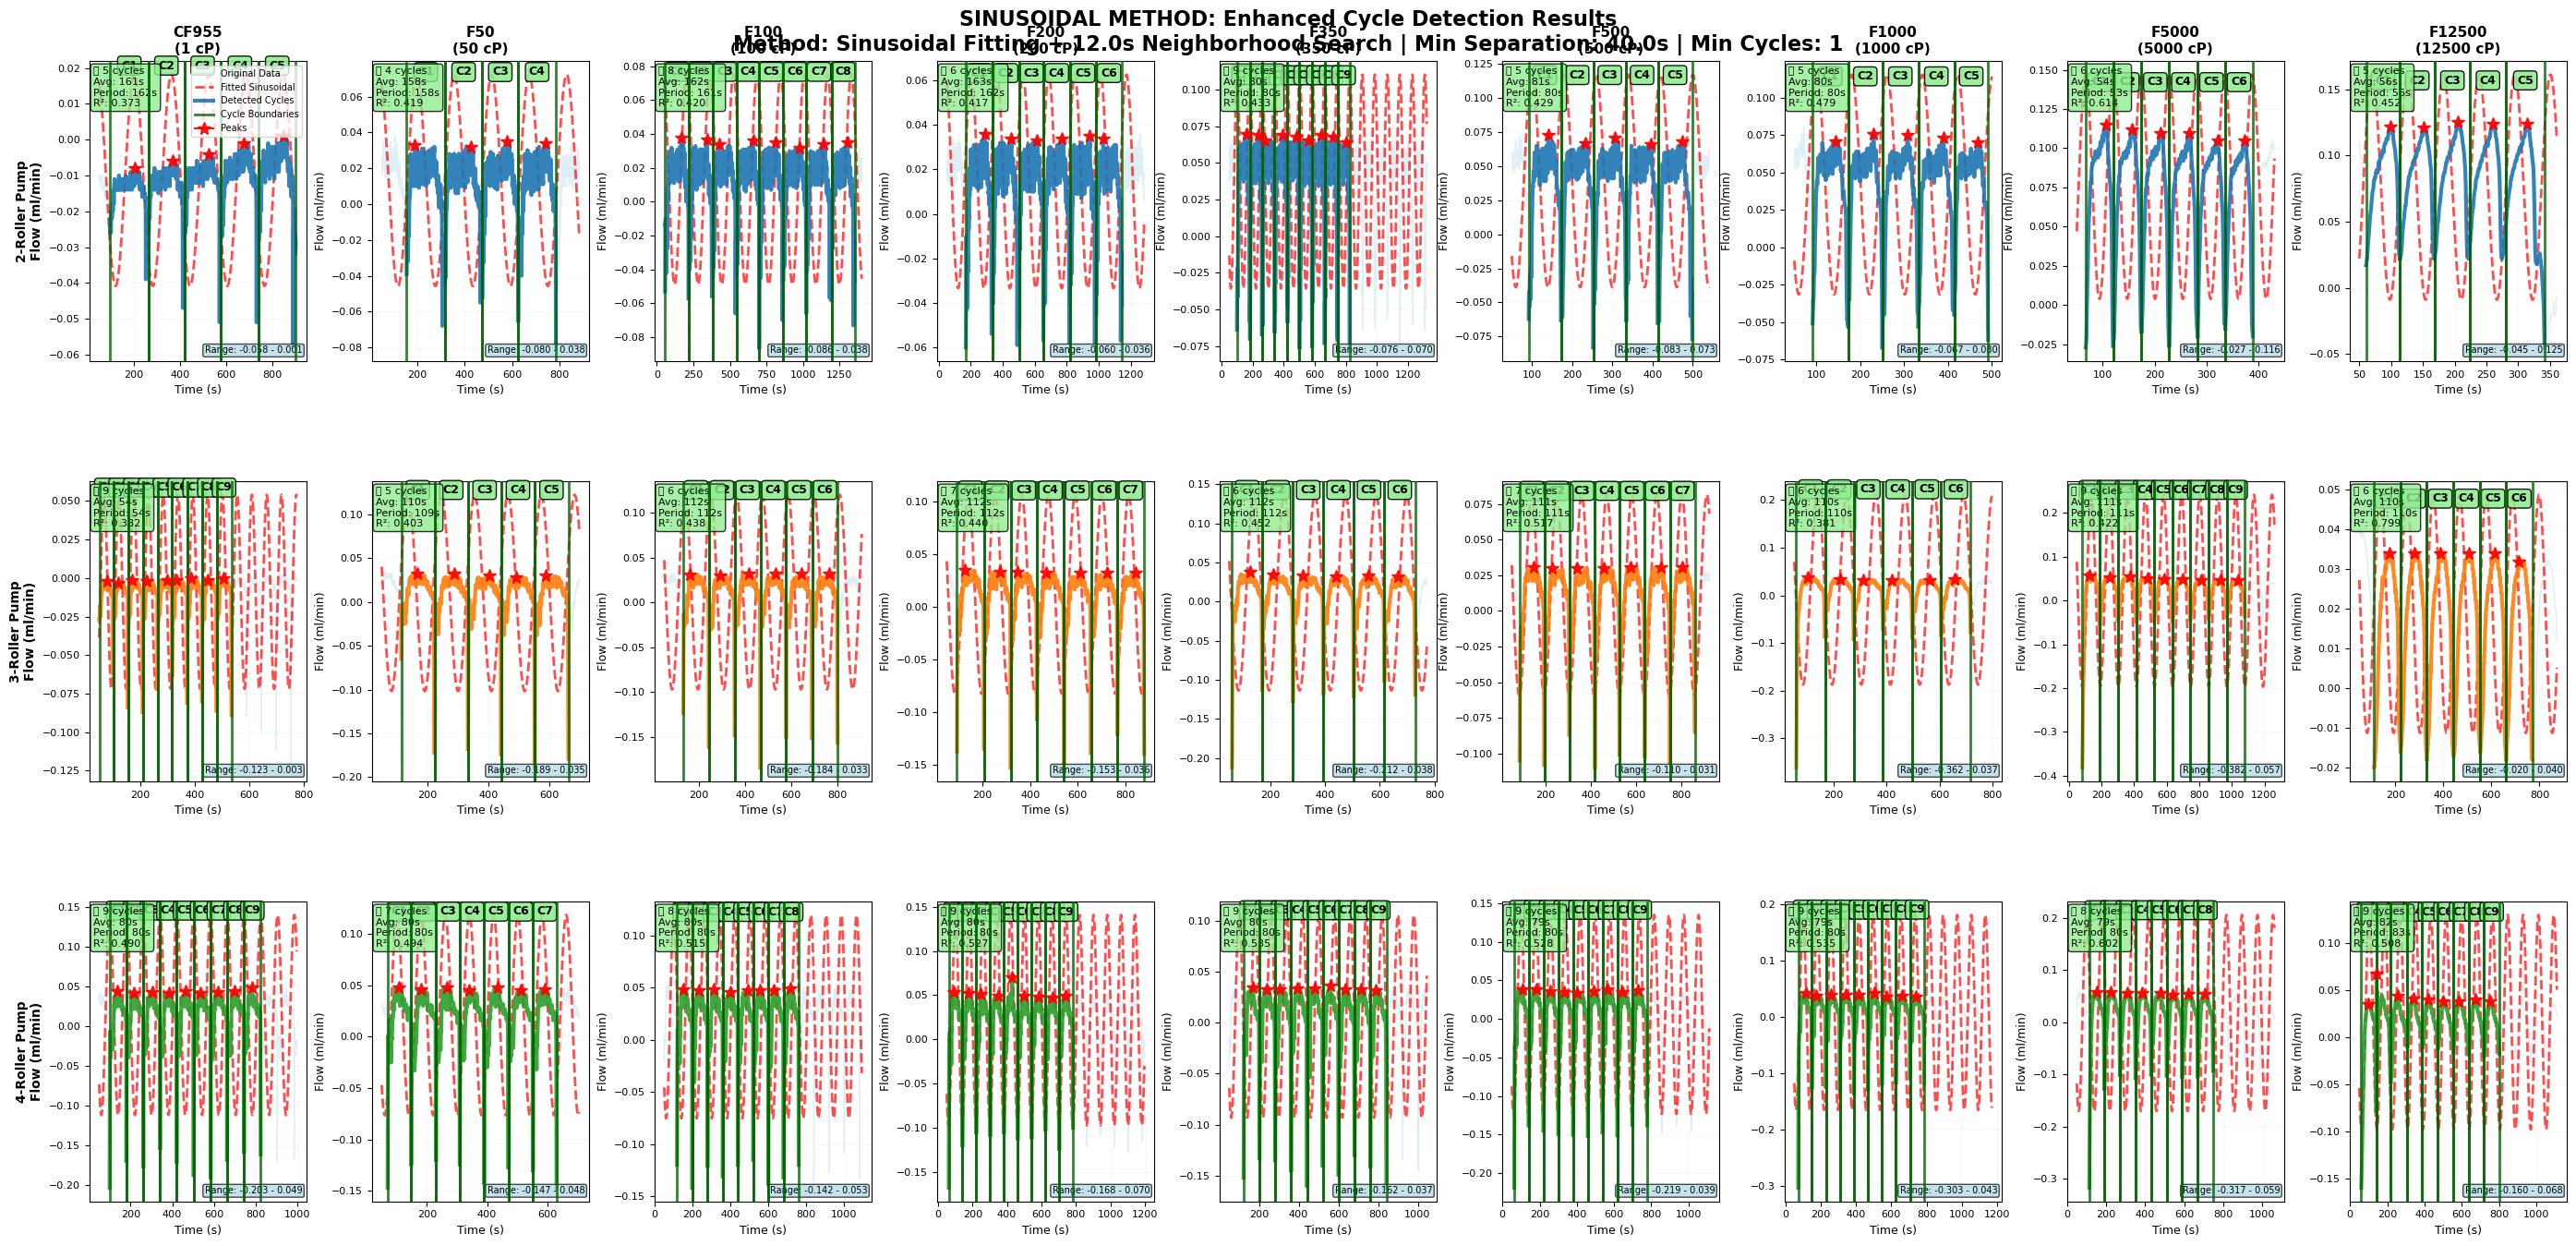

✅ VISUALIZATION COMPLETE
🎯 Displayed results for 3 datasets across 9 liquid types


In [772]:
# ===================================================================
# COMPREHENSIVE VISUALIZATION
# ===================================================================

def create_results_visualization(results, datasets_dict):
    """Create comprehensive visualization of cycle detection results"""
    dataset_names = list(datasets_dict.keys())
    liquid_names = list(LIQUIDS_INFO.keys())[:MAX_LIQUIDS_TO_ANALYZE]
    
    # Create subplot grid
    fig, axes = plt.subplots(len(dataset_names), len(liquid_names), figsize=FIGURE_SIZE)
    if len(dataset_names) == 1:
        axes = axes.reshape(1, -1)
    
    # Main title
    title = (f'SINUSOIDAL METHOD: Enhanced Cycle Detection Results\n'
             f'Method: Sinusoidal Fitting + {SINUSOIDAL_SEARCH_WINDOW_SEC}s Neighborhood Search | '
             f'Min Separation: {MIN_TIME_SEPARATION_SEC}s | Min Cycles: {MIN_CYCLES_REQUIRED}')
    fig.suptitle(title, fontsize=16, fontweight='bold', y=0.96)
    
    # Colors for each pump configuration
    pump_colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
    
    # Plot each combination
    for dataset_idx, (dataset_name, df) in enumerate(datasets_dict.items()):
        dataset_results = results['datasets'][dataset_name]
        pump_color = pump_colors[dataset_idx]
        
        for liquid_idx, liquid_col in enumerate(liquid_names):
            ax = axes[dataset_idx, liquid_idx]
            liquid_name = liquid_col.replace('_flow_ml_min', '')
            liquid_info = LIQUIDS_INFO[liquid_col]
            
            # Get data
            time_data = df['time_s'].values
            flow_data = df[liquid_col].values
            
            # Plot original data
            ax.plot(time_data, flow_data, alpha=0.4, linewidth=1, color='lightblue', 
                   label='Original Data', zorder=1)
            
            # Process results if available
            if liquid_name in dataset_results['liquid_results']:
                liquid_result = dataset_results['liquid_results'][liquid_name]
                cycles = liquid_result['cycles']
                
                if cycles and liquid_result['successful']:
                    # Plot fitted sinusoidal curve
                    valid_mask = ~np.isnan(flow_data) & ~np.isnan(time_data)
                    if np.sum(valid_mask) > 0:
                        valid_time = time_data[valid_mask]
                        sort_indices = np.argsort(valid_time)
                        valid_time_sorted = valid_time[sort_indices]
                        
                        # Generate fitted curve using parameters from first cycle
                        cycle = cycles[0]
                        fitted_period = cycle['fitted_period']
                        
                        # Simplified fitted curve for visualization
                        C_fit = np.mean(flow_data[valid_mask])
                        A_fit = (np.max(flow_data[valid_mask]) - np.min(flow_data[valid_mask])) / 2
                        omega_fit = 2 * np.pi / fitted_period
                        phi_fit = 0  # Simplified for visualization
                        
                        fitted_values = A_fit * np.sin(omega_fit * valid_time_sorted + phi_fit) + C_fit
                        ax.plot(valid_time_sorted, fitted_values, color='red', linewidth=2, 
                               alpha=0.7, label='Fitted Sinusoidal', linestyle='--', zorder=2)
                    
                    # Plot detected cycles
                    for cycle_idx, cycle in enumerate(cycles):
                        cycle_time = cycle['cycle_time']
                        cycle_flow = cycle['cycle_flow']
                        
                        # Highlight detected cycle
                        ax.plot(cycle_time, cycle_flow, color=pump_color, linewidth=3, 
                               alpha=0.9, label='Detected Cycles' if cycle_idx == 0 else '', zorder=3)
                        
                        # Mark cycle boundaries
                        ax.axvline(cycle['start_time'], color='darkgreen', alpha=0.8, linestyle='-', 
                                  linewidth=2, label='Cycle Boundaries' if cycle_idx == 0 else '', zorder=4)
                        ax.axvline(cycle['end_time'], color='darkgreen', alpha=0.8, linestyle='-', 
                                  linewidth=2, zorder=4)
                        
                        # Mark peaks
                        ax.plot(cycle['peak_time'], cycle['peak_flow'], marker='*', 
                               color='red', markersize=10, alpha=0.9, zorder=5,
                               label='Peaks' if cycle_idx == 0 else '')
                        
                        # Cycle number annotation
                        mid_time = (cycle['start_time'] + cycle['end_time']) / 2
                        ax.text(mid_time, ax.get_ylim()[1] * 0.90, f'C{cycle_idx+1}', 
                               ha='center', fontsize=9, fontweight='bold',
                               bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgreen', alpha=0.9))
                    
                    # Success statistics
                    avg_duration = liquid_result.get('avg_duration', 0)
                    fitted_period = liquid_result.get('fitted_period', 0)
                    r_squared = liquid_result.get('avg_fit_r_squared', 0)
                    
                    success_text = (f'✅ {len(cycles)} cycles\n'
                                   f'Avg: {avg_duration:.0f}s\n'
                                   f'Period: {fitted_period:.0f}s\n'
                                   f'R²: {r_squared:.3f}')
                    ax.text(0.02, 0.98, success_text, transform=ax.transAxes, fontsize=8,
                           verticalalignment='top', bbox=dict(boxstyle='round,pad=0.3', 
                           facecolor='lightgreen', alpha=0.8))
                
                else:
                    # Failure indicator
                    cycles_found = len(cycles) if cycles else 0
                    fail_text = f'❌ {cycles_found} cycles\n(< {MIN_CYCLES_REQUIRED} required)'
                    
                    ax.text(0.5, 0.5, fail_text, transform=ax.transAxes, ha='center', va='center',
                           fontsize=10, color='red', fontweight='bold',
                           bbox=dict(boxstyle='round,pad=0.4', facecolor='mistyrose', alpha=0.8))
                
                # Flow range information
                flow_range = liquid_result.get('flow_range', (np.nan, np.nan))
                flow_stats = f'Range: {flow_range[0]:.3f} - {flow_range[1]:.3f}'
                ax.text(0.98, 0.02, flow_stats, transform=ax.transAxes, fontsize=7,
                       verticalalignment='bottom', horizontalalignment='right',
                       bbox=dict(boxstyle='round,pad=0.2', facecolor='lightblue', alpha=0.7))
            
            # Formatting
            ax.grid(True, alpha=0.3, linestyle=':', linewidth=0.5)
            ax.set_xlabel('Time (s)', fontsize=9)
            
            # Titles and labels
            if dataset_idx == 0:
                ax.set_title(f'{liquid_info["name"]}\n({liquid_info["viscosity"]})', 
                           fontsize=11, fontweight='bold')
            
            if liquid_idx == 0:
                ax.set_ylabel(f'{dataset_name}\nFlow (ml/min)', fontsize=10, fontweight='bold')
            else:
                ax.set_ylabel('Flow (ml/min)', fontsize=9)
            
            ax.tick_params(labelsize=8)
            
            # Legend on first subplot
            if dataset_idx == 0 and liquid_idx == 0:
                ax.legend(loc='upper right', fontsize=7, ncol=1)
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.92, hspace=0.4, wspace=0.3)
    return fig

# Create and display visualization
print("🎨 Creating comprehensive results visualization...")
results_figure = create_results_visualization(pipeline_results, datasets)
plt.show()

print("✅ VISUALIZATION COMPLETE")
print(f"🎯 Displayed results for {len(datasets)} datasets across {MAX_LIQUIDS_TO_ANALYZE} liquid types")

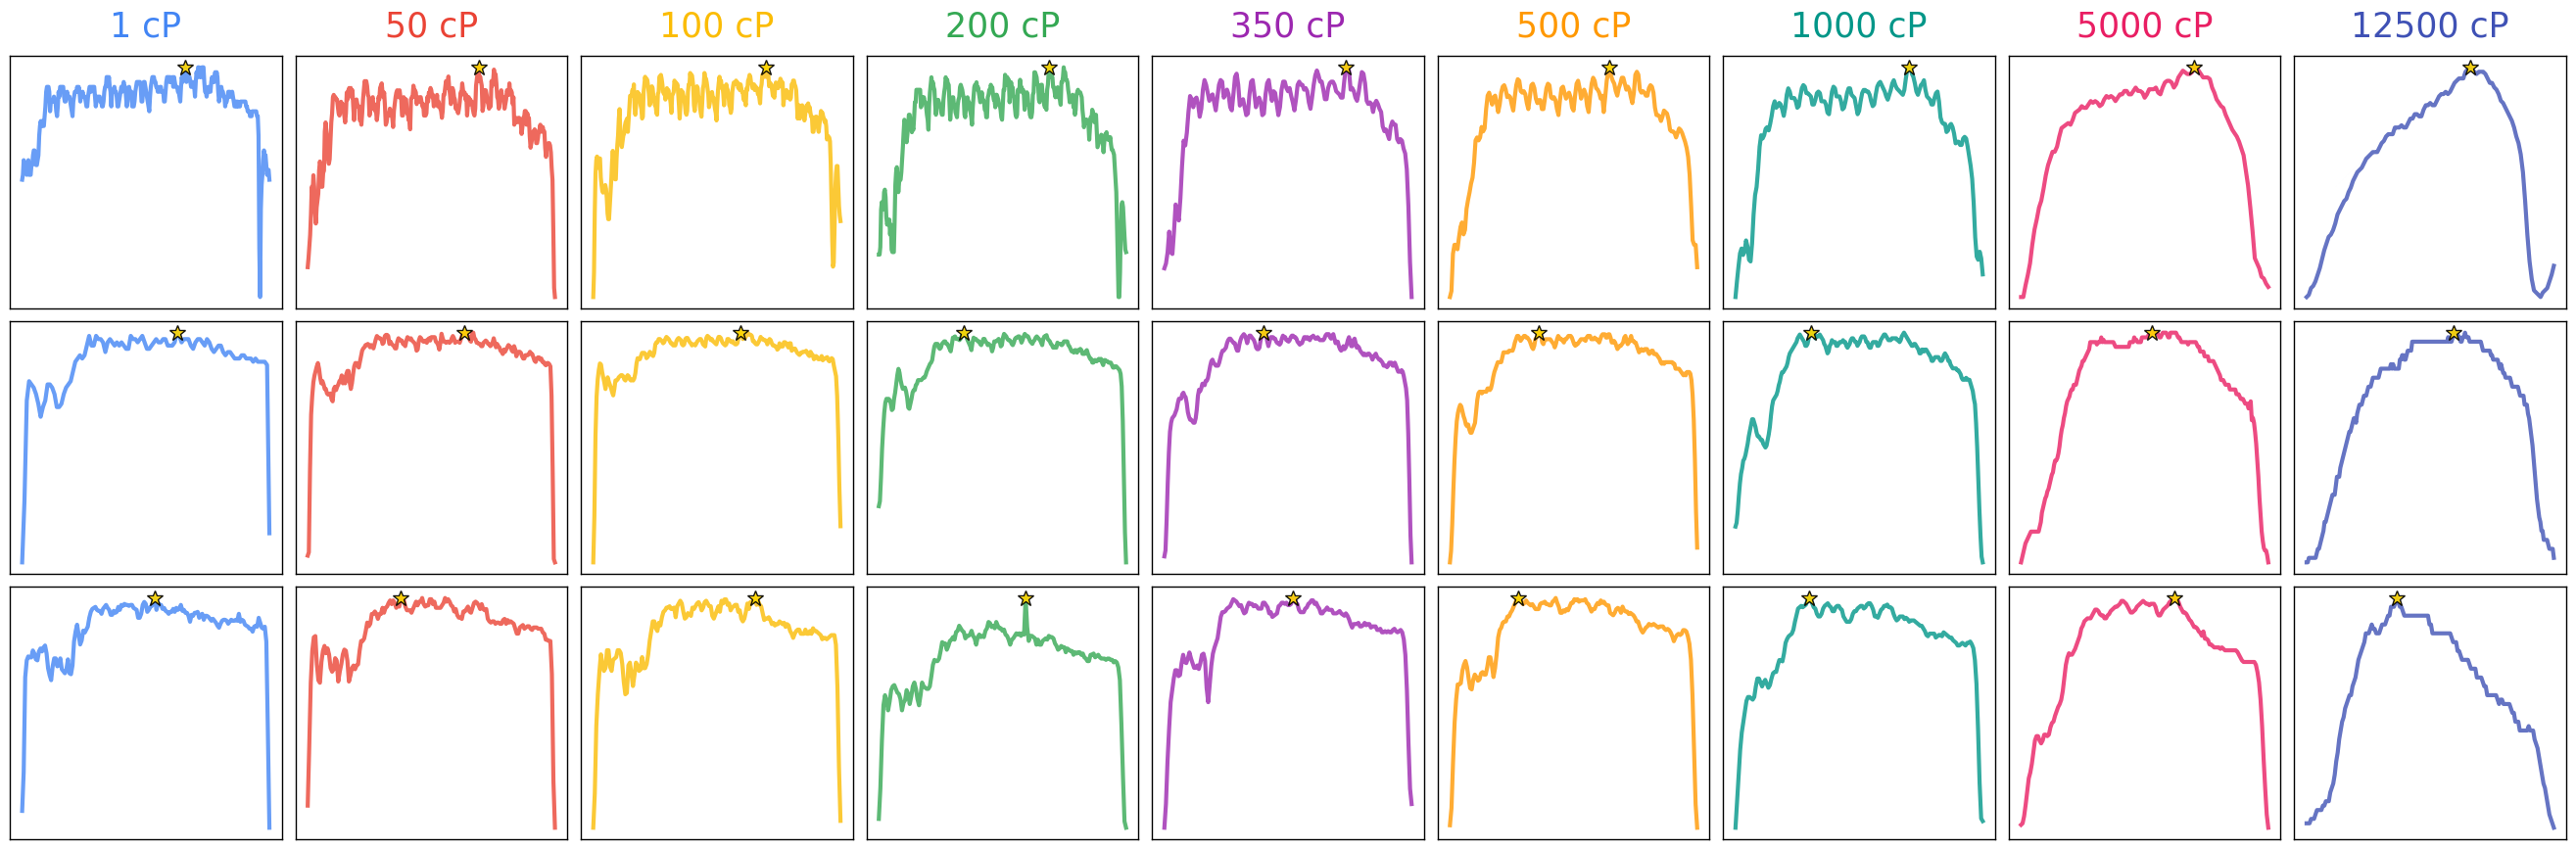

In [773]:
# ===================================================================
# SINGLE CYCLE VISUALIZATION GRID (3x9)
# ===================================================================

def create_single_cycle_grid(results, datasets_dict):
    """Create 3x9 grid showing single representative cycles for each pump-sample combination"""
    
    # Google color palette
    google_colors = {
        'blue': '#4285F4',
        'red': '#EA4335', 
        'yellow': '#FBBC04',
        'green': '#34A853',
        'purple': '#9C27B0',
        'orange': '#FF9800',
        'teal': '#009688',
        'pink': '#E91E63',
        'indigo': '#3F51B5'
    }
    
    dataset_names = list(datasets_dict.keys())  # ['2-Roller Pump', '3-Roller Pump', '4-Roller Pump']
    liquid_names = list(LIQUIDS_INFO.keys())[:MAX_LIQUIDS_TO_ANALYZE]
    color_list = list(google_colors.values())
    
    # Create 3x9 subplot grid with increased height
    fig, axes = plt.subplots(3, 9, figsize=(30, 10))
    
    # Plot each combination
    for dataset_idx, dataset_name in enumerate(dataset_names):
        dataset_results = results['datasets'][dataset_name]
        
        for liquid_idx, liquid_col in enumerate(liquid_names):
            ax = axes[dataset_idx, liquid_idx]
            liquid_name = liquid_col.replace('_flow_ml_min', '')
            liquid_info = LIQUIDS_INFO[liquid_col]
            
            # Get color for this liquid
            color = color_list[liquid_idx % len(color_list)]
            
            # Clear the plot
            ax.clear()
            
            # Process results if available
            if liquid_name in dataset_results['liquid_results']:
                liquid_result = dataset_results['liquid_results'][liquid_name]
                
                if liquid_result['successful'] and liquid_result['cycles']:
                    # Get middle cycle as representative
                    middle_idx = len(liquid_result['cycles']) // 2
                    cycle = liquid_result['cycles'][middle_idx]
                    cycle_time = cycle['cycle_time']
                    cycle_flow = cycle['cycle_flow']
                    
                    # Normalize time to start from 0 for better comparison
                    normalized_time = cycle_time - cycle['start_time']
                    
                    # Plot the single cycle with smooth line
                    ax.plot(normalized_time, cycle_flow, color=color, linewidth=3, 
                           alpha=0.8)
                    
                    # Mark peak
                    peak_idx = np.argmax(cycle_flow)
                    ax.plot(normalized_time[peak_idx], cycle_flow[peak_idx], marker='*', 
                           color='gold', markersize=12, markeredgecolor='black', 
                           markeredgewidth=1, alpha=0.9, zorder=6)
                    
                    # Set individual X-axis range for this cycle
                    time_margin = (max(normalized_time) - min(normalized_time)) * 0.05
                    if time_margin > 0:
                        xlim_individual = (min(normalized_time) - time_margin, max(normalized_time) + time_margin)
                    else:
                        xlim_individual = (min(normalized_time) - 5, max(normalized_time) + 5)
                    
                    ax.set_xlim(xlim_individual)
                    
                    # Set individual Y-axis range for this cycle
                    flow_margin = (max(cycle_flow) - min(cycle_flow)) * 0.05
                    if flow_margin > 0:
                        ylim_individual = (min(cycle_flow) - flow_margin, max(cycle_flow) + flow_margin)
                    else:
                        ylim_individual = (min(cycle_flow) - 0.1, max(cycle_flow) + 0.1)
                    
                    ax.set_ylim(ylim_individual)
                    
                else:
                    # No successful cycle found
                    ax.text(0.5, 0.5, 'No\nCycles\nDetected', 
                           transform=ax.transAxes, ha='center', va='center',
                           fontsize=14, color='red', fontweight='bold',
                           bbox=dict(boxstyle='round,pad=0.4', facecolor='mistyrose', alpha=0.8))
                    ax.set_xlim(0, 100)  # Default x-range for failed cases
                    ax.set_ylim(0, 1)    # Default y-range for failed cases
            
            else:
                # No data available
                ax.text(0.5, 0.5, 'No\nData\nAvailable', 
                       transform=ax.transAxes, ha='center', va='center',
                       fontsize=14, color='gray', fontweight='bold',
                       bbox=dict(boxstyle='round,pad=0.4', facecolor='lightgray', alpha=0.8))
                ax.set_xlim(0, 100)  # Default x-range for no data cases
                ax.set_ylim(0, 1)    # Default y-range for no data cases
            
            # Formatting
            ax.grid(True, alpha=0.3, linestyle=':', linewidth=0.5)
            ax.tick_params(labelsize=10)
            
            # Set all borders (spines) to black
            for spine in ax.spines.values():
                spine.set_color('black')
                spine.set_linewidth(1)

            # Column headers (liquid names) - only on top row
            if dataset_idx == 0:
                ax.set_title(f'{liquid_info["viscosity"]}', 
                           fontsize=25, color=color, pad=15)
            
            ax.set_xticks([])
            ax.set_yticks([])
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.88, bottom=0.08, left=0.08, right=0.95, hspace=0.05, wspace=0.05)
    
    return fig

# Create and display the single cycle grid visualization
single_cycle_fig = create_single_cycle_grid(pipeline_results, datasets)
plt.show()


🎨 Creating comprehensive phase detection visualization...
📊 Processing cycles with smoothing and phase boundary detection...


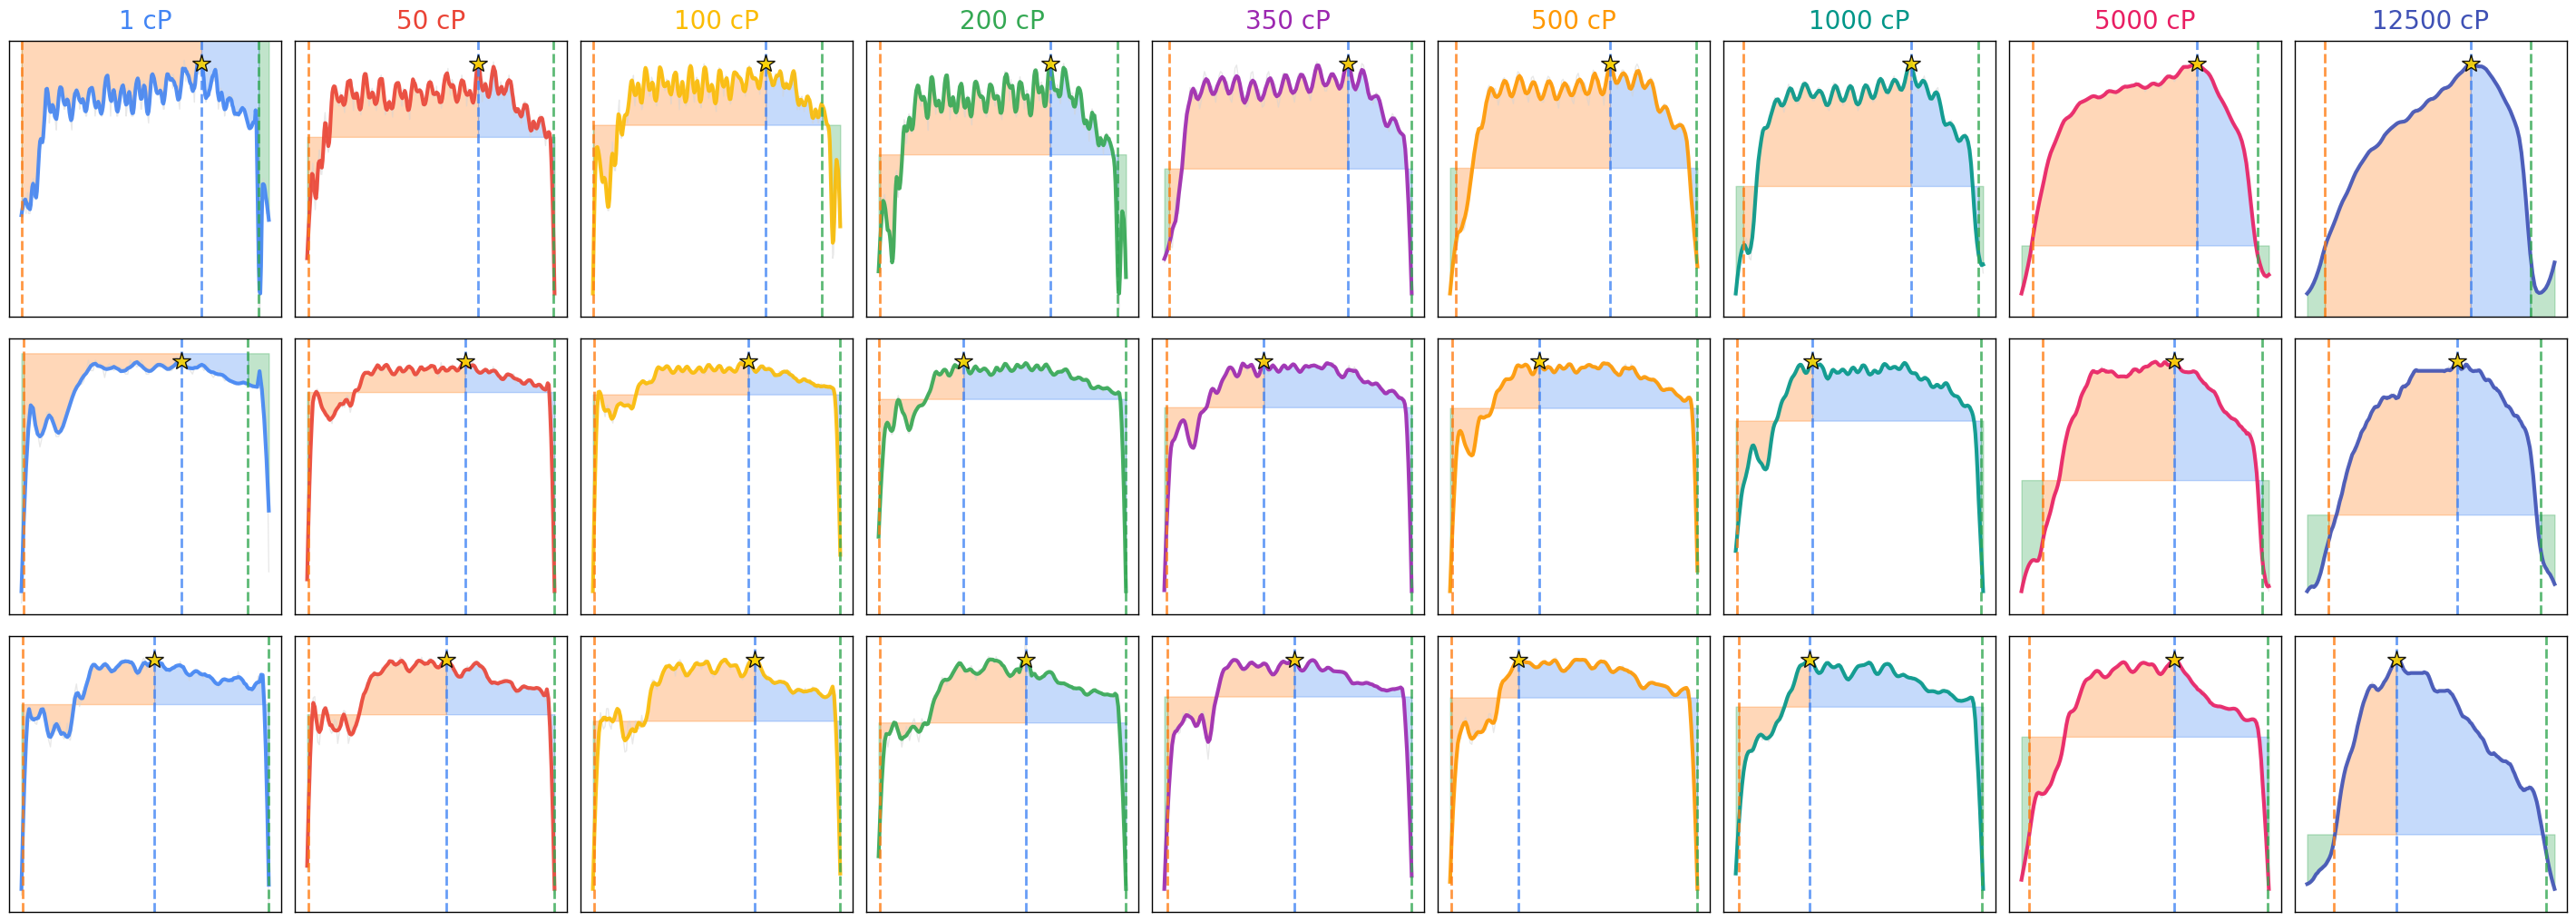

In [774]:
# ===================================================================
# COMPREHENSIVE PHASE DETECTION VISUALIZATION (3x9 GRID)
# ===================================================================

def create_phase_detection_grid(results, datasets_dict):
    """Create 3x9 grid showing cycles with detected phases for each pump-sample combination"""
    
    # Google color palette for samples
    google_colors = {
        'blue': '#4285F4',
        'red': '#EA4335', 
        'yellow': '#FBBC04',
        'green': '#34A853',
        'purple': '#9C27B0',
        'orange': '#FF9800',
        'teal': '#009688',
        'pink': '#E91E63',
        'indigo': '#3F51B5'
    }
    
    # Phase colors for visualization
    phase_colors = {
        'phase1': "#34A853",  # Red - Initial Ramp
        'phase2': '#FF7D14',  # Teal - Rise to Peak
        'phase3': '#4285F4',  # Blue - Peak to Final
        'phase4': "#34A853"   # Green - Final Descent
    }
    
    dataset_names = list(datasets_dict.keys())  # ['2-Roller Pump', '3-Roller Pump', '4-Roller Pump']
    liquid_names = list(LIQUIDS_INFO.keys())[:MAX_LIQUIDS_TO_ANALYZE]
    color_list = list(google_colors.values())
    
    # Create 3x9 subplot grid with increased height
    fig, axes = plt.subplots(3, 9, figsize=(30, 12))
    
    # Plot each combination
    for dataset_idx, dataset_name in enumerate(dataset_names):
        dataset_results = results['datasets'][dataset_name]
        
        for liquid_idx, liquid_col in enumerate(liquid_names):
            ax = axes[dataset_idx, liquid_idx]
            liquid_name = liquid_col.replace('_flow_ml_min', '')
            liquid_info = LIQUIDS_INFO[liquid_col]
            
            # Get color for this liquid
            color = color_list[liquid_idx % len(color_list)]
            
            # Clear the plot
            ax.clear()
            
            # Process results if available
            if liquid_name in dataset_results['liquid_results']:
                liquid_result = dataset_results['liquid_results'][liquid_name]
                
                if liquid_result['successful'] and liquid_result['cycles']:
                    # Get middle cycle as representative
                    middle_idx = len(liquid_result['cycles']) // 2
                    cycle = liquid_result['cycles'][middle_idx]
                    
                    # Apply smoothing and phase detection
                    filtered_data = apply_savitzky_filter(cycle, window_length=9, polyorder=2)
                    
                    if filtered_data:
                        phases = detect_cycle_phases(filtered_data)
                        
                        if phases:
                            # Get data
                            time_orig = filtered_data['time_orig']
                            flow_orig = filtered_data['flow_orig']
                            flow_smooth = filtered_data['flow_smooth']
                            
                            # Normalize time to start from 0 for better comparison
                            normalized_time = time_orig - time_orig[0]
                            
                            # Plot original data as light background
                            ax.plot(normalized_time, flow_orig, color='lightgray', linewidth=1, 
                                   alpha=0.5, label='Original')
                            
                            # Plot smoothed data as main line
                            ax.plot(normalized_time, flow_smooth, color=color, linewidth=3, 
                                   alpha=0.9, label='Smoothed')
                            
                            # Plot phase boundaries and segments
                            phase_names = ['Phase 1\n(Initial)', 'Phase 2\n(Rise)', 'Phase 3\n(Peak)', 'Phase 4\n(Descent)']
                            phase_keys = ['phase1', 'phase2', 'phase3', 'phase4']
                            
                            for i, (phase_key, phase_name) in enumerate(zip(phase_keys, phase_names)):
                                start_idx = phases[f'{phase_key}_start']
                                end_idx = phases[f'{phase_key}_end']
                                
                                # Highlight phase segment
                                phase_time = normalized_time[start_idx:end_idx+1]
                                phase_flow = flow_smooth[start_idx:end_idx+1]
                                
                                ax.fill_between(phase_time, 0, phase_flow, 
                                              color=phase_colors[phase_key], alpha=0.3,
                                              label=phase_name if dataset_idx == 0 and liquid_idx == 0 else "")
                                
                                # Add phase boundary lines
                                if i > 0:  # Don't draw line at the very beginning
                                    ax.axvline(normalized_time[start_idx], color=phase_colors[phase_key], 
                                             alpha=0.8, linestyle='--', linewidth=2)
                            
                            # Mark peak with special marker
                            peak_idx = phases['peak_idx']
                            ax.plot(normalized_time[peak_idx], flow_smooth[peak_idx], 
                                   marker='*', color='gold', markersize=15, 
                                   markeredgecolor='black', markeredgewidth=1, 
                                   alpha=0.9, zorder=10, label='Peak' if dataset_idx == 0 and liquid_idx == 0 else "")
                            
                            # Set individual axis ranges
                            time_margin = (max(normalized_time) - min(normalized_time)) * 0.05
                            if time_margin > 0:
                                xlim_individual = (min(normalized_time) - time_margin, max(normalized_time) + time_margin)
                            else:
                                xlim_individual = (min(normalized_time) - 2, max(normalized_time) + 2)
                            
                            ax.set_xlim(xlim_individual)
                            
                            flow_margin = (max(flow_smooth) - min(flow_smooth)) * 0.1
                            if flow_margin > 0:
                                ylim_individual = (min(flow_smooth) - flow_margin, max(flow_smooth) + flow_margin)
                            else:
                                ylim_individual = (min(flow_smooth) - 0.1, max(flow_smooth) + 0.1)
                            
                            ax.set_ylim(ylim_individual)

                            
                        else:
                            # Phase detection failed, show smoothed data only
                            time_orig = filtered_data['time_orig']
                            flow_smooth = filtered_data['flow_smooth']
                            normalized_time = time_orig - time_orig[0]
                            
                            ax.plot(normalized_time, flow_smooth, color=color, linewidth=3, alpha=0.8)
                            ax.text(0.5, 0.5, 'Phase Detection\nFailed', 
                                   transform=ax.transAxes, ha='center', va='center',
                                   fontsize=12, color='orange', fontweight='bold',
                                   bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', alpha=0.8))
                    
                    else:
                        # Smoothing failed, show original data
                        cycle_time = cycle['cycle_time']
                        cycle_flow = cycle['cycle_flow']
                        normalized_time = cycle_time - cycle['start_time']
                        
                        ax.plot(normalized_time, cycle_flow, color=color, linewidth=3, alpha=0.8)
                        ax.text(0.5, 0.5, 'Smoothing\nFailed', 
                               transform=ax.transAxes, ha='center', va='center',
                               fontsize=12, color='red', fontweight='bold',
                               bbox=dict(boxstyle='round,pad=0.4', facecolor='mistyrose', alpha=0.8))
                
                else:
                    # No successful cycle found
                    ax.text(0.5, 0.5, 'No\nCycles\nDetected', 
                           transform=ax.transAxes, ha='center', va='center',
                           fontsize=14, color='red', fontweight='bold',
                           bbox=dict(boxstyle='round,pad=0.4', facecolor='mistyrose', alpha=0.8))
                    ax.set_xlim(0, 100)
                    ax.set_ylim(0, 1)
            
            else:
                # No data available
                ax.text(0.5, 0.5, 'No\nData\nAvailable', 
                       transform=ax.transAxes, ha='center', va='center',
                       fontsize=14, color='gray', fontweight='bold',
                       bbox=dict(boxstyle='round,pad=0.4', facecolor='lightgray', alpha=0.8))
                ax.set_xlim(0, 100)
                ax.set_ylim(0, 1)
            
            # Formatting
            ax.grid(True, alpha=0.2, linestyle=':', linewidth=0.5)
            ax.tick_params(labelsize=10)
            
            # Set all borders (spines) to black
            for spine in ax.spines.values():
                spine.set_color('black')
                spine.set_linewidth(1)

            # Column headers (liquid names) - only on top row
            if dataset_idx == 0:
                ax.set_title(f'{liquid_info["viscosity"]}', 
                           fontsize=20, color=color, pad=10)
            
            # Remove all tick labels for cleaner look
            ax.set_xticks([])
            ax.set_yticks([])
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.85, bottom=0.05, left=0.03, right=0.97, hspace=0.08, wspace=0.05)
    
    return fig

# Create and display the phase detection visualization
print("🎨 Creating comprehensive phase detection visualization...")
print("📊 Processing cycles with smoothing and phase boundary detection...")

phase_detection_fig = create_phase_detection_grid(pipeline_results, datasets)
plt.show()

# print("✅ PHASE DETECTION VISUALIZATION COMPLETE")
# print("🎯 Each subplot shows:")
# print("   - Gray line: Original cycle data")
# print("   - Colored line: Smoothed cycle data") 
# print("   - Colored regions: Detected phases (Initial→Rise→Peak→Descent)")
# print("   - Gold star: Peak location")
# print("   - Dashed lines: Phase boundaries")
# print("   - Text box: Phase durations in seconds")

🎯 Creating focused phase detection visualization for 4-Roller Pump with 1000 cP liquid...
📊 Generating single-panel phase analysis with Google color scheme...


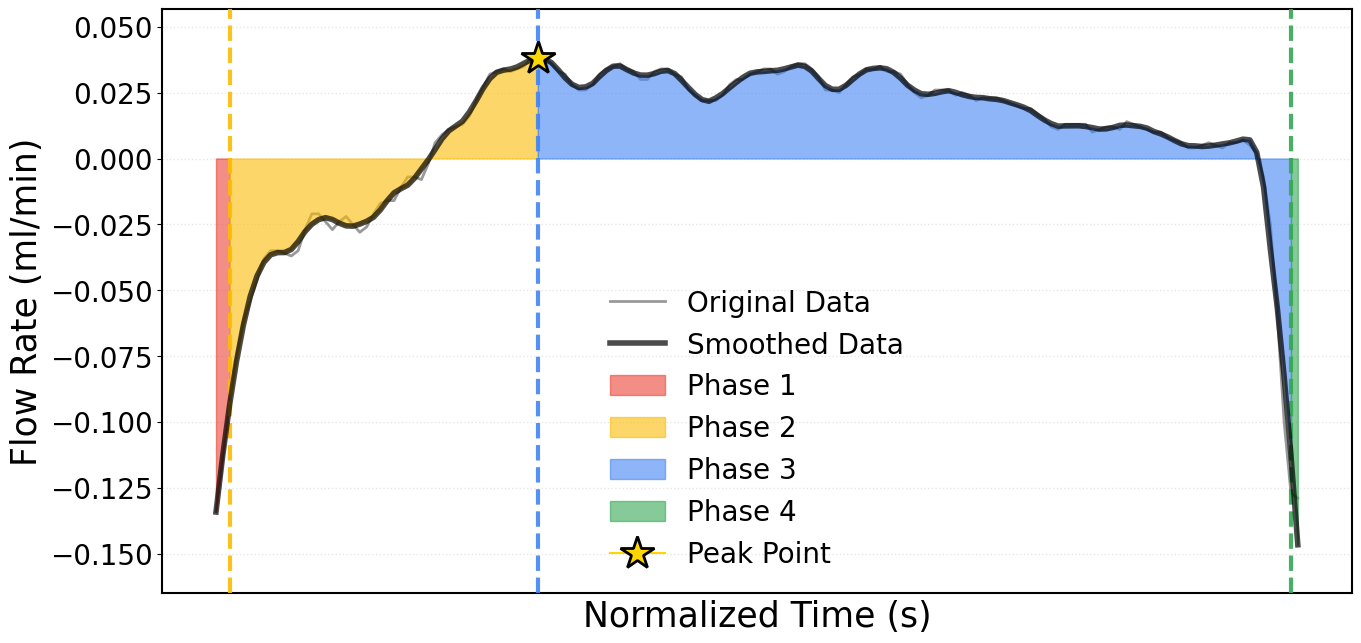

In [775]:
# ===================================================================
# FOCUSED PHASE ANALYSIS: 4-ROLLER PUMP WITH 1000 cP LIQUID
# ===================================================================

def create_focused_phase_analysis(results, datasets_dict, target_pump='4-Roller Pump', target_liquid='F1000'):
    """Create detailed phase analysis visualization for specific pump-liquid combination"""
    
    # Google color palette - more distinguishable colors
    phase_colors = {
        'phase1': '#EA4335',  # Google Red - Initial Ramp
        'phase2': '#FBBC04',  # Google Yellow - Rise to Peak  
        'phase3': '#4285F4',  # Google Blue - Peak to Final
        'phase4': '#34A853'   # Google Green - Final Descent
    }
    
    # Create single figure for phase detection
    fig, ax = plt.subplots(1, 1, figsize=(14, 8))
    
    # Get the specific dataset and liquid data
    if target_pump in results['datasets']:
        dataset_results = results['datasets'][target_pump]
        
        if target_liquid in dataset_results['liquid_results']:
            liquid_result = dataset_results['liquid_results'][target_liquid]
            
            if liquid_result['successful'] and liquid_result['cycles']:
                # Get middle cycle as representative
                middle_idx = len(liquid_result['cycles']) // 2
                cycle = liquid_result['cycles'][middle_idx]
                
                # Apply smoothing and phase detection
                filtered_data = apply_savitzky_filter(cycle, window_length=9, polyorder=2)
                
                if filtered_data and filtered_data is not None:
                    phases = detect_cycle_phases(filtered_data)
                    
                    if phases:
                        # Get data
                        time_orig = filtered_data['time_orig']
                        flow_orig = filtered_data['flow_orig']
                        flow_smooth = filtered_data['flow_smooth']
                        
                        # Normalize time to start from 0
                        normalized_time = time_orig - time_orig[0]
                        
                        # Plot original data as light background
                        ax.plot(normalized_time, flow_orig, color='black', linewidth=2, 
                                alpha=0.4, label='Original Data')
                        
                        # Plot smoothed data as main line
                        ax.plot(normalized_time, flow_smooth, color='black', linewidth=4, 
                                alpha=0.7, label='Smoothed Data', zorder=5)
                        
                        # Plot phase segments with fill
                        phase_names = ['Phase 1', 'Phase 2', 'Phase 3', 'Phase 4']
                        phase_keys = ['phase1', 'phase2', 'phase3', 'phase4']
                        
                        for i, (phase_key, phase_name) in enumerate(zip(phase_keys, phase_names)):
                            start_idx = phases[f'{phase_key}_start']
                            end_idx = phases[f'{phase_key}_end']
                            
                            phase_time = normalized_time[start_idx:end_idx+1]
                            phase_flow = flow_smooth[start_idx:end_idx+1]
                            
                            # Fill between with stronger alpha for better visibility
                            ax.fill_between(phase_time, 0, phase_flow, 
                                           color=phase_colors[phase_key], alpha=0.6, 
                                           label=phase_name, zorder=2)
                            
                            # Add phase boundary lines with matching colors
                            if i > 0:
                                ax.axvline(normalized_time[start_idx], color=phase_colors[phase_key], 
                                          alpha=0.9, linestyle='--', linewidth=3, zorder=4)
                        
                        # Mark peak with special marker
                        peak_idx = phases['peak_idx']
                        ax.plot(normalized_time[peak_idx], flow_smooth[peak_idx], 
                                marker='*', color='gold', markersize=25, 
                                markeredgecolor='black', markeredgewidth=2, 
                                alpha=1.0, zorder=10, label='Peak Point')
                                                
                        # Calculate phase durations for subtitle
                        phase_durations = {
                            'P1': normalized_time[phases['phase1_end']] - normalized_time[phases['phase1_start']],
                            'P2': normalized_time[phases['phase2_end']] - normalized_time[phases['phase2_start']],
                            'P3': normalized_time[phases['phase3_end']] - normalized_time[phases['phase3_start']],
                            'P4': normalized_time[phases['phase4_end']] - normalized_time[phases['phase4_start']]
                        }

                        
                        ax.set_xlabel('Normalized Time (s)', fontsize=25)
                        ax.set_ylabel('Flow Rate (ml/min)', fontsize=25)
                        ax.grid(True, alpha=0.3, linestyle=':', linewidth=1)
                        ax.legend(loc='lower center', fontsize=20, frameon=False)
                        
                        # Set nice axis limits with some padding
                        time_margin = (max(normalized_time) - min(normalized_time)) * 0.05
                        flow_margin = (max(flow_smooth) - min(flow_smooth)) * 0.1
                        ax.set_xlim(min(normalized_time) - time_margin, max(normalized_time) + time_margin)
                        ax.set_ylim(min(flow_smooth) - flow_margin, max(flow_smooth) + flow_margin)
                        
                        # Improve tick formatting
                        ax.set_xticks([])  # Remove x-axis numbers
                        ax.tick_params(axis='y', labelsize=20)  # Set y-axis fontsize to 20
                        
                        # Set solid black borders with thicker linewidth
                        for spine in ax.spines.values():
                            spine.set_color('black')
                            spine.set_linewidth(1.5)
                            spine.set_linestyle('-')
                        
                    else:
                        # Phase detection failed
                        ax.text(0.5, 0.5, 'Phase Detection Failed', 
                               transform=ax.transAxes, ha='center', va='center',
                               fontsize=18, color='red', fontweight='bold')
                        ax.set_title(f'4-Roller Pump - 1000 cP: Phase Detection Failed', 
                                    fontsize=16, fontweight='bold')
                
                else:
                    # Smoothing failed
                    ax.text(0.5, 0.5, 'Data Smoothing Failed', 
                           transform=ax.transAxes, ha='center', va='center',
                           fontsize=18, color='red', fontweight='bold')
                    ax.set_title(f'4-Roller Pump - 1000 cP: Smoothing Failed', 
                                fontsize=16, fontweight='bold')
            
            else:
                # No successful cycles
                ax.text(0.5, 0.5, 'No Cycles Detected', 
                       transform=ax.transAxes, ha='center', va='center',
                       fontsize=18, color='red', fontweight='bold')
                ax.set_title(f'4-Roller Pump - 1000 cP: No Cycles Detected', 
                            fontsize=16, fontweight='bold')
        
        else:
            # Liquid not found
            ax.text(0.5, 0.5, f'Liquid {target_liquid} Not Found', 
                   transform=ax.transAxes, ha='center', va='center',
                   fontsize=18, color='gray', fontweight='bold')
            ax.set_title(f'4-Roller Pump - 1000 cP: Data Not Available', 
                        fontsize=16, fontweight='bold')
    
    else:
        # Pump not found
        ax.text(0.5, 0.5, f'Pump {target_pump} Not Found', 
               transform=ax.transAxes, ha='center', va='center',
               fontsize=18, color='gray', fontweight='bold')
        ax.set_title(f'{target_pump}: Data Not Available', fontsize=16, fontweight='bold')
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.85, bottom=0.12, left=0.10, right=0.95)
    
    return fig

# Create and display the focused phase analysis
print("🎯 Creating focused phase detection visualization for 4-Roller Pump with 1000 cP liquid...")
print("📊 Generating single-panel phase analysis with Google color scheme...")

focused_analysis_fig = create_focused_phase_analysis(pipeline_results, datasets, 
                                                   target_pump='4-Roller Pump', 
                                                   target_liquid='F1000')
plt.show()


In [ ]:
# ===================================================================
# CUSTOM SIGMOID FUNCTION FITTING FOR ALL DETECTED CYCLES
# ===================================================================

def custom_sigmoid_function(x, M, L, R, N, z, a, b, v, H, c):
    """
    Custom sigmoid function with the form:
    y = H * [1/(1+exp(-(x-M)/z)) + 1/(1+exp(-(x-L)/(0.1*a))) - 1/(1+exp(-(x-R)/(0.1*b))) - 1/(1+exp(-(x-N)/(0.1*v)))] + c
    
    Parameters:
    - M, L, R, N: position parameters for the four sigmoid components
    - z, a, b, v: slope parameters for the four sigmoid components
    - H: amplitude scaling factor (must be positive)
    - c: vertical offset (can be negative)
    
    Constraints:
    - All parameters except c must be positive
    - All parameters must be below 10
    - M < L < R < N (ordering constraint)
    - M is in first 30% of cycle time, N is in last 30% of cycle time
    """
    term1 = 1 / (1 + np.exp(-(x - M) / z))
    term2 = 1 / (1 + np.exp(-(x - L) / (0.1 * a)))
    term3 = 1 / (1 + np.exp(-(x - R) / (0.1 * b)))
    term4 = 1 / (1 + np.exp(-(x - N) / (0.1 * v)))
    
    return H * (term1 + term2 - term3 - term4) + c

def fit_custom_sigmoid_to_cycle(cycle_data, max_attempts=10):
    """
    Fit the custom sigmoid function to a single cycle with robust parameter initialization
    
    Parameter Update Strategy:
    - Attempt 0: Base initialization with target positions
    - Attempt 1-2: Add small noise to base positions
    - Attempt 3-5: Add medium noise and relax constraints slightly
    - Attempt 6-9: Add large noise and use broader initialization ranges
    
    Constraints: M in first 30%, N in last 30%, and M < L < R < N
    """
    cycle_time = cycle_data['cycle_time']
    cycle_flow = cycle_data['cycle_flow']
    
    # Normalize time to start from 0 for better numerical stability
    normalized_time = cycle_time - cycle_time[0]
    
    # Calculate basic statistics for parameter initialization
    flow_min = np.min(cycle_flow)
    flow_max = np.max(cycle_flow)
    flow_range = flow_max - flow_min
    time_range = np.max(normalized_time) - np.min(normalized_time)
    
    # Define time constraints for M and N
    M_max_time = time_range * 0.3  # M must be in first 30%
    N_min_time = time_range * 0.7  # N must be in last 30%
    
    # Find peak location for better initialization
    peak_idx = np.argmax(cycle_flow)
    peak_time = normalized_time[peak_idx]
    
    for attempt in range(max_attempts):
        try:
            # Adaptive parameter initialization - gets more flexible with each attempt
            noise_factor = 0.05 + 0.1 * attempt  # Gradually increase noise
            flexibility = min(1.0, 0.2 + 0.1 * attempt)  # Increase flexibility
            
            # Base positions - get more spread out with attempts
            if attempt < 3:
                # Conservative initialization
                M_base = time_range * 0.15  # 15% through cycle
                L_base = time_range * 0.35  # 35% through cycle
                R_base = time_range * 0.65  # 65% through cycle
                N_base = time_range * 0.85  # 85% through cycle
            else:
                # More flexible initialization
                M_base = time_range * (0.05 + 0.2 * np.random.random())  # 5-25%
                L_base = time_range * (0.25 + 0.3 * np.random.random())  # 25-55%
                R_base = time_range * (0.45 + 0.3 * np.random.random())  # 45-75%
                N_base = time_range * (0.75 + 0.2 * np.random.random())  # 75-95%
            
            # Add noise to base positions
            M_noise = np.random.normal(0, time_range * noise_factor * 0.1)
            L_noise = np.random.normal(0, time_range * noise_factor * 0.1)
            R_noise = np.random.normal(0, time_range * noise_factor * 0.1)
            N_noise = np.random.normal(0, time_range * noise_factor * 0.1)
            
            # Initialize positions with proper ordering
            M_init = max(0.01, min(M_max_time * 0.9, M_base + M_noise))
            L_init = max(M_init + time_range * 0.05, L_base + L_noise)
            R_init = max(L_init + time_range * 0.05, R_base + R_noise)
            N_init = max(max(N_min_time * 1.1, R_init + time_range * 0.05), 
                        min(time_range * 0.95, N_base + N_noise))
            
            # Initialize slope parameters with more variation
            base_slope = time_range * (0.1 + 0.3 * np.random.random())
            z_init = max(0.1, min(5.0, base_slope + np.random.normal(0, base_slope * noise_factor)))
            a_init = max(0.1, min(5.0, base_slope + np.random.normal(0, base_slope * noise_factor)))
            b_init = max(0.1, min(5.0, base_slope + np.random.normal(0, base_slope * noise_factor)))
            v_init = max(0.1, min(5.0, base_slope + np.random.normal(0, base_slope * noise_factor)))
            
            # Initialize H based on flow range
            H_init = max(0.1, min(8.0, flow_range * (1.0 + np.random.normal(0, noise_factor))))
            
            # Initialize C as offset from minimum
            c_init = max(-5.0, min(5.0, flow_min + np.random.normal(0, flow_range * noise_factor * 0.5)))
            
            # More flexible bounds that still enforce constraints
            bounds_lower = [
                0.01,                    # M: positive
                M_init + 0.01,          # L: greater than M
                L_init + 0.01,          # R: greater than L  
                max(N_min_time, R_init + 0.01),  # N: in last 30% and greater than R
                0.01, 0.01, 0.01, 0.01, # z, a, b, v: positive
                0.01,                    # H: positive
                -8.0                     # c: can be negative
            ]
            
            bounds_upper = [
                M_max_time,             # M: in first 30%
                time_range,             # L: within time range
                time_range,             # R: within time range
                time_range,             # N: within time range
                8.0, 8.0, 8.0, 8.0,    # z, a, b, v: reasonable slopes
                10.0,                   # H: reasonable amplitude
                8.0                     # c: reasonable offset
            ]
            
            bounds = (bounds_lower, bounds_upper)
            
            # Initial parameter vector
            p0 = [M_init, L_init, R_init, N_init, z_init, a_init, b_init, v_init, H_init, c_init]
            
            # Perform curve fitting
            fitted_params, covariance = curve_fit(
                custom_sigmoid_function, 
                normalized_time, 
                cycle_flow,
                p0=p0,
                bounds=bounds,
                maxfev=8000,
                method='trf'
            )
            
            # Extract fitted parameters for validation
            M_fit, L_fit, R_fit, N_fit = fitted_params[:4]
            z_fit, a_fit, b_fit, v_fit, H_fit, c_fit = fitted_params[4:]
            
            # Validate constraints
            ordering_ok = M_fit < L_fit < R_fit < N_fit
            position_ok = M_fit <= M_max_time and N_fit >= N_min_time
            bounds_ok = (all(p > 0 for p in fitted_params[:9]) and 
                        all(p < 10 for p in fitted_params[:9]) and 
                        abs(c_fit) < 10)
            
            if not (ordering_ok and position_ok and bounds_ok):
                raise ValueError(f"Constraint violation: M={M_fit:.3f}, L={L_fit:.3f}, R={R_fit:.3f}, N={N_fit:.3f}")
            
            # Calculate fit quality
            fitted_values = custom_sigmoid_function(normalized_time, *fitted_params)
            ss_res = np.sum((cycle_flow - fitted_values) ** 2)
            ss_tot = np.sum((cycle_flow - np.mean(cycle_flow)) ** 2)
            r_squared = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0
            param_errors = np.sqrt(np.diag(covariance)) if covariance is not None else np.full(10, np.nan)
            
            # Print successful fit info for debugging
            if attempt > 0:
                print(f"   ✅ Success on attempt {attempt + 1}: R²={r_squared:.3f}")
            
            return {
                'success': True,
                'fitted_params': fitted_params,
                'param_names': ['M', 'L', 'R', 'N', 'z', 'a', 'b', 'v', 'H', 'c'],
                'param_errors': param_errors,
                'fitted_values': fitted_values,
                'normalized_time': normalized_time,
                'original_time': cycle_time,
                'original_flow': cycle_flow,
                'r_squared': r_squared,
                'attempt': attempt + 1
            }
            
        except Exception as e:
            # Print more detailed error info for debugging
            if attempt < 3:
                print(f"   Attempt {attempt + 1} failed: {str(e)[:80]}")
            
            if attempt == max_attempts - 1:
                print(f"   ❌ All {max_attempts} attempts failed. Last error: {str(e)[:100]}")
                return {
                    'success': False,
                    'error': str(e),
                    'normalized_time': normalized_time,
                    'original_time': cycle_time,
                    'original_flow': cycle_flow,
                    'attempts_made': max_attempts
                }
            continue

def fit_sigmoid_to_all_cycles(pipeline_results):
    """
    Fit custom sigmoid function to all detected cycles in pipeline results
    """
    print("🔧 FITTING CUSTOM SIGMOID FUNCTION TO ALL DETECTED CYCLES")
    print("=" * 60)
    
    fitting_results = {
        'datasets': {},
        'summary': {
            'total_cycles': 0,
            'successful_fits': 0,
            'failed_fits': 0,
            'success_rate': 0.0
        }
    }
    
    for dataset_name, dataset_data in pipeline_results['datasets'].items():
        print(f"\n📊 Processing {dataset_name}...")
        
        dataset_fitting = {
            'liquids': {},
            'successful_fits': 0,
            'failed_fits': 0,
            'total_cycles': 0
        }
        
        for liquid_name, liquid_result in dataset_data['liquid_results'].items():
            if liquid_result['successful'] and liquid_result['cycles']:
                liquid_fitting = {
                    'cycles': [],
                    'successful_fits': 0,
                    'failed_fits': 0
                }
                
                print(f"   🎯 {liquid_name}: {len(liquid_result['cycles'])} cycles...", end=' ')
                
                for cycle_idx, cycle in enumerate(liquid_result['cycles']):
                    fit_result = fit_custom_sigmoid_to_cycle(cycle)
                    fit_result['cycle_number'] = cycle_idx + 1
                    fit_result['liquid_name'] = liquid_name
                    fit_result['dataset_name'] = dataset_name
                    
                    liquid_fitting['cycles'].append(fit_result)
                    dataset_fitting['total_cycles'] += 1
                    fitting_results['summary']['total_cycles'] += 1
                    
                    if fit_result['success']:
                        liquid_fitting['successful_fits'] += 1
                        dataset_fitting['successful_fits'] += 1
                        fitting_results['summary']['successful_fits'] += 1
                    else:
                        liquid_fitting['failed_fits'] += 1
                        dataset_fitting['failed_fits'] += 1
                        fitting_results['summary']['failed_fits'] += 1
                
                # Calculate liquid-level statistics
                total_liquid_cycles = liquid_fitting['successful_fits'] + liquid_fitting['failed_fits']
                liquid_success_rate = liquid_fitting['successful_fits'] / total_liquid_cycles * 100 if total_liquid_cycles > 0 else 0
                
                print(f"✅ {liquid_fitting['successful_fits']}/{total_liquid_cycles} ({liquid_success_rate:.0f}%)")
                
                dataset_fitting['liquids'][liquid_name] = liquid_fitting
            
            else:
                print(f"   ⏭️  {liquid_name}: No cycles to fit")
        
        fitting_results['datasets'][dataset_name] = dataset_fitting
        
        # Dataset summary
        dataset_success_rate = dataset_fitting['successful_fits'] / dataset_fitting['total_cycles'] * 100 if dataset_fitting['total_cycles'] > 0 else 0
        print(f"   📈 Dataset success: {dataset_fitting['successful_fits']}/{dataset_fitting['total_cycles']} ({dataset_success_rate:.1f}%)")
    
    # Calculate overall summary
    fitting_results['summary']['success_rate'] = fitting_results['summary']['successful_fits'] / fitting_results['summary']['total_cycles'] * 100 if fitting_results['summary']['total_cycles'] > 0 else 0
    
    print(f"\n📊 SIGMOID FITTING SUMMARY:")
    print(f"   🎯 Total cycles processed: {fitting_results['summary']['total_cycles']}")
    print(f"   ✅ Successful fits: {fitting_results['summary']['successful_fits']}")
    print(f"   ❌ Failed fits: {fitting_results['summary']['failed_fits']}")
    print(f"   📈 Overall success rate: {fitting_results['summary']['success_rate']:.1f}%")
    
    return fitting_results

# Execute sigmoid fitting on all detected cycles
sigmoid_fitting_results = fit_sigmoid_to_all_cycles(pipeline_results)

🔧 FITTING CUSTOM SIGMOID FUNCTION TO ALL DETECTED CYCLES

📊 Processing 2-Roller Pump...
   🎯 CF955: 5 cycles...    ❌ Fitting failed after 10 attempts: Each lower bound must be strictly less than each upper bound.
   ❌ Fitting failed after 10 attempts: Each lower bound must be strictly less than each upper bound.
   ❌ Fitting failed after 10 attempts: Each lower bound must be strictly less than each upper bound.
   ❌ Fitting failed after 10 attempts: Each lower bound must be strictly less than each upper bound.
   ❌ Fitting failed after 10 attempts: Each lower bound must be strictly less than each upper bound.
✅ 0/5 (0%)
   🎯 F50: 4 cycles...    ❌ Fitting failed after 10 attempts: Each lower bound must be strictly less than each upper bound.
   ❌ Fitting failed after 10 attempts: Each lower bound must be strictly less than each upper bound.
   ❌ Fitting failed after 10 attempts: Each lower bound must be strictly less than each upper bound.
   ❌ Fitting failed after 10 attempts: Each low

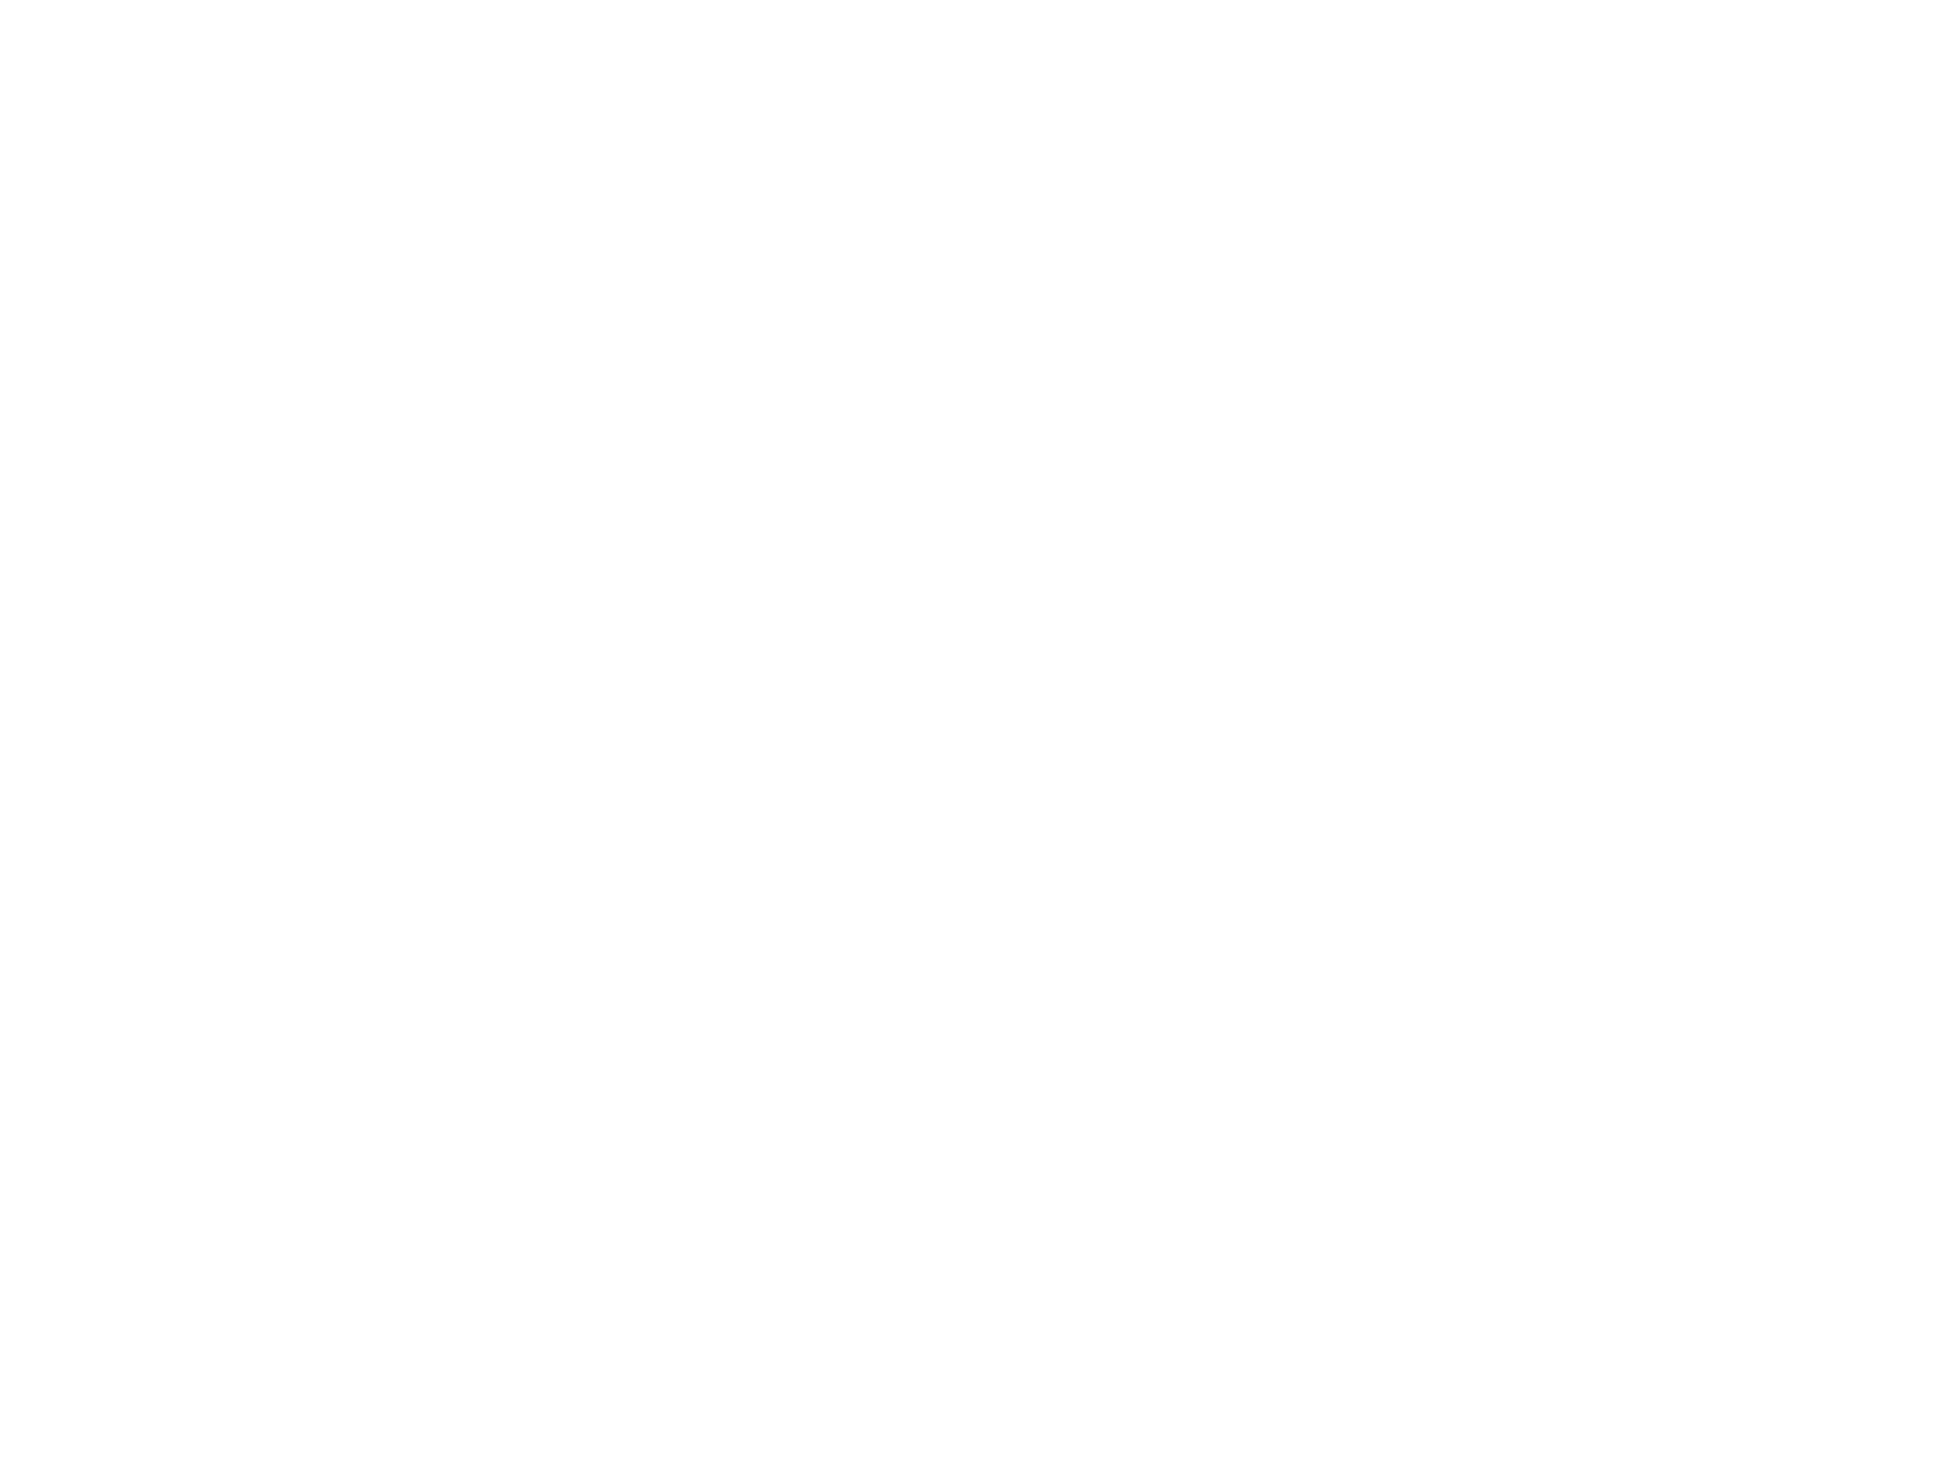

In [777]:
# ===================================================================
# COMPREHENSIVE SIGMOID FITTING VISUALIZATION
# ===================================================================

def create_sigmoid_fitting_visualization(sigmoid_results, datasets_dict):
    """Create comprehensive visualization showing original cycles and fitted sigmoid curves"""
    dataset_names = list(datasets_dict.keys())
    liquid_names = list(LIQUIDS_INFO.keys())[:MAX_LIQUIDS_TO_ANALYZE]
    
    # Create subplot grid with larger figure size
    fig, axes = plt.subplots(len(dataset_names), len(liquid_names), figsize=(20, 15))
    if len(dataset_names) == 1:
        axes = axes.reshape(1, -1)
    
    # Colors for each pump configuration
    pump_colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
    
    # Plot each combination
    for dataset_idx, (dataset_name, df) in enumerate(datasets_dict.items()):
        if dataset_name not in sigmoid_results['datasets']:
            continue
            
        dataset_results = sigmoid_results['datasets'][dataset_name]
        pump_color = pump_colors[dataset_idx]
        
        for liquid_idx, liquid_col in enumerate(liquid_names):
            ax = axes[dataset_idx, liquid_idx]
            liquid_name = liquid_col.replace('_flow_ml_min', '')
            liquid_info = LIQUIDS_INFO[liquid_col]
            
            # Process sigmoid fitting results if available
            if liquid_name in dataset_results['liquids']:
                liquid_fitting = dataset_results['liquids'][liquid_name]
                cycles_with_fits = liquid_fitting['cycles']
                
                successful_cycles = [c for c in cycles_with_fits if c['success']]
                
                if successful_cycles:
                    # Select middle cycle as representative
                    middle_idx = len(successful_cycles) // 2
                    cycle_fit = successful_cycles[middle_idx]
                    
                    original_time = cycle_fit['original_time']
                    original_flow = cycle_fit['original_flow']
                    fitted_values = cycle_fit['fitted_values']
                    r_squared = cycle_fit['r_squared']
                    
                    # Normalize time to start from 0 for better comparison across subplots
                    normalized_time = original_time - original_time[0]
                    
                    # Plot original cycle data (transparent)
                    ax.plot(normalized_time, original_flow, color=pump_color, linewidth=3, 
                           alpha=0.3, zorder=3)
                    
                    # Plot fitted sigmoid curve (solid line)
                    ax.plot(normalized_time, fitted_values, color='red', linewidth=3, 
                           alpha=0.9, linestyle='-', zorder=4)
                    
                    # Adjust x-axis to focus on the cycle with some padding
                    time_range = normalized_time[-1] - normalized_time[0]
                    padding = time_range * 0.1  # 10% padding on each side
                    ax.set_xlim(normalized_time[0] - padding, normalized_time[-1] + padding)
                    
                    # Adjust y-axis to focus on the cycle flow range
                    flow_range = np.max(original_flow) - np.min(original_flow)
                    flow_padding = flow_range * 0.1  # 10% padding on top and bottom
                    ax.set_ylim(np.min(original_flow) - flow_padding, 
                               np.max(original_flow) + flow_padding)
            
            # Remove all axis labels, ticks, and numbers
            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_xlabel('')
            ax.set_ylabel('')
            
            # Remove grid and spines for cleaner look
            ax.grid(False)
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.spines['bottom'].set_visible(False)
            ax.spines['left'].set_visible(False)
    
    # Minimize spacing between subplots to make visualization bigger
    plt.subplots_adjust(left=0.02, bottom=0.02, right=0.98, top=0.98, 
                        wspace=0.05, hspace=0.05)
    return fig

# Create and display comprehensive sigmoid fitting visualization
sigmoid_fitting_figure = create_sigmoid_fitting_visualization(sigmoid_fitting_results, datasets)
plt.show()

In [778]:
# ===================================================================
# SIGMOID PARAMETER ANALYSIS & STATISTICS
# ===================================================================

def analyze_sigmoid_parameters(sigmoid_results):
    """Analyze the fitted sigmoid parameters across all successful fits"""
    print("📊 SIGMOID PARAMETER ANALYSIS")
    print("=" * 60)
    
    # Collect all successful parameter sets
    all_params = []
    param_names = ['M', 'L', 'R', 'N', 'z', 'a', 'b', 'v', 'H', 'c']
    
    for dataset_name, dataset_data in sigmoid_results['datasets'].items():
        for liquid_name, liquid_data in dataset_data['liquids'].items():
            for cycle_fit in liquid_data['cycles']:
                if cycle_fit['success']:
                    param_dict = {
                        'dataset': dataset_name,
                        'liquid': liquid_name,
                        'cycle': cycle_fit['cycle_number'],
                        'r_squared': cycle_fit['r_squared']
                    }
                    
                    # Add parameter values
                    for i, param_name in enumerate(param_names):
                        param_dict[param_name] = cycle_fit['fitted_params'][i]
                        param_dict[f'{param_name}_error'] = cycle_fit['param_errors'][i] if not np.isnan(cycle_fit['param_errors'][i]) else 0
                    
                    all_params.append(param_dict)
    
    if not all_params:
        print("❌ No successful parameter fits to analyze")
        return None
    
    # Convert to DataFrame for analysis
    params_df = pd.DataFrame(all_params)
    
    print(f"📈 Analyzing {len(params_df)} successful sigmoid fits")
    print(f"   Datasets: {params_df['dataset'].nunique()}")
    print(f"   Liquids: {params_df['liquid'].nunique()}")
    print(f"   Average R²: {params_df['r_squared'].mean():.4f} ± {params_df['r_squared'].std():.4f}")
    
    # Parameter statistics
    print(f"\n📊 PARAMETER STATISTICS:")
    print("-" * 60)
    
    param_stats = {}
    for param in param_names:
        if param in params_df.columns:
            values = params_df[param].values
            valid_values = values[~np.isnan(values)]
            
            if len(valid_values) > 0:
                param_stats[param] = {
                    'mean': np.mean(valid_values),
                    'std': np.std(valid_values),
                    'min': np.min(valid_values),
                    'max': np.max(valid_values),
                    'median': np.median(valid_values)
                }
                
                print(f"{param:>2}: {param_stats[param]['mean']:8.3f} ± {param_stats[param]['std']:6.3f} "
                      f"[{param_stats[param]['min']:8.3f}, {param_stats[param]['max']:8.3f}] "
                      f"(median: {param_stats[param]['median']:7.3f})")
    
    # R² distribution by dataset and liquid
    print(f"\n🎯 R² DISTRIBUTION BY DATASET:")
    print("-" * 40)
    for dataset in params_df['dataset'].unique():
        dataset_data = params_df[params_df['dataset'] == dataset]
        avg_r2 = dataset_data['r_squared'].mean()
        std_r2 = dataset_data['r_squared'].std()
        count = len(dataset_data)
        print(f"{dataset:>15}: {avg_r2:.4f} ± {std_r2:.4f} ({count} fits)")
    
    print(f"\n🧪 R² DISTRIBUTION BY LIQUID:")
    print("-" * 40)
    for liquid in params_df['liquid'].unique():
        liquid_data = params_df[params_df['liquid'] == liquid]
        avg_r2 = liquid_data['r_squared'].mean()
        std_r2 = liquid_data['r_squared'].std()
        count = len(liquid_data)
        
        # Get viscosity info
        liquid_col = f"{liquid}_flow_ml_min"
        viscosity = LIQUIDS_INFO.get(liquid_col, {}).get('viscosity', 'Unknown')
        print(f"{liquid:>8} ({viscosity:>8}): {avg_r2:.4f} ± {std_r2:.4f} ({count} fits)")
    
    return {
        'params_df': params_df,
        'param_stats': param_stats,
        'summary': {
            'total_successful_fits': len(params_df),
            'avg_r_squared': params_df['r_squared'].mean(),
            'std_r_squared': params_df['r_squared'].std(),
            'datasets_analyzed': params_df['dataset'].nunique(),
            'liquids_analyzed': params_df['liquid'].nunique()
        }
    }

def create_parameter_distribution_plots(param_analysis):
    """Create parameter distribution visualization"""
    if param_analysis is None:
        return None
    
    params_df = param_analysis['params_df']
    param_names = ['M', 'L', 'R', 'N', 'z', 'a', 'b', 'v', 'H', 'c']
    
    # Create subplot grid for parameter distributions (2x5 for 10 parameters)
    fig, axes = plt.subplots(2, 5, figsize=(25, 10))
    axes = axes.flatten()
    
    colors = plt.cm.Set3(np.linspace(0, 1, len(param_names)))
    
    for i, param in enumerate(param_names):
        ax = axes[i]
        
        if param in params_df.columns:
            values = params_df[param].values
            valid_values = values[~np.isnan(values)]
            
            if len(valid_values) > 0:
                # Histogram
                ax.hist(valid_values, bins=min(20, len(valid_values)//2), 
                       alpha=0.7, color=colors[i], edgecolor='black')
                
                # Statistics
                mean_val = np.mean(valid_values)
                std_val = np.std(valid_values)
                
                ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, 
                          label=f'Mean: {mean_val:.3f}')
                ax.axvline(mean_val + std_val, color='orange', linestyle=':', linewidth=1, alpha=0.7)
                ax.axvline(mean_val - std_val, color='orange', linestyle=':', linewidth=1, alpha=0.7,
                          label=f'±1σ: {std_val:.3f}')
                
                ax.set_title(f'Parameter {param}\n(n={len(valid_values)} fits)', fontsize=12, fontweight='bold')
                ax.set_xlabel(f'{param} value', fontsize=10)
                ax.set_ylabel('Frequency', fontsize=10)
                ax.legend(fontsize=8)
                ax.grid(True, alpha=0.3)
        
        else:
            ax.text(0.5, 0.5, f'No data for\nparameter {param}', 
                   ha='center', va='center', transform=ax.transAxes,
                   fontsize=12, color='gray')
            ax.set_title(f'Parameter {param}', fontsize=12)
    
    plt.suptitle('Sigmoid Parameter Distributions Across All Successful Fits', 
                 fontsize=16, fontweight='bold', y=0.95)
    plt.tight_layout()
    plt.subplots_adjust(top=0.90)
    
    return fig

# Analyze sigmoid parameters and create visualizations
parameter_analysis = analyze_sigmoid_parameters(sigmoid_fitting_results)

if parameter_analysis:
    print("\n🎨 Creating parameter distribution plots...")
    param_dist_figure = create_parameter_distribution_plots(parameter_analysis)
    if param_dist_figure:
        plt.show()
    
    print(f"\n✅ SIGMOID PARAMETER ANALYSIS COMPLETE")
    print(f"🎯 Successfully analyzed {parameter_analysis['summary']['total_successful_fits']} sigmoid fits")
    print(f"📈 Overall fitting quality: R² = {parameter_analysis['summary']['avg_r_squared']:.4f} ± {parameter_analysis['summary']['std_r_squared']:.4f}")
else:
    print("❌ No successful sigmoid fits available for parameter analysis")

📊 SIGMOID PARAMETER ANALYSIS
❌ No successful parameter fits to analyze
❌ No successful sigmoid fits available for parameter analysis
